# TECHNICAL TERMS

1. **Reinforcement Learning (RL)** – A learning method where an agent learns by interacting with an environment and receiving rewards or penalties for its actions.

2. **Agent** – The decision-making entity that takes actions in the environment to maximize total reward.

3. **Environment** – The world or system in which the agent operates and learns through interaction.

4. **Action** – A step or move taken by the agent that affects the environment’s state.

5. **State** – The current situation or condition of the environment that the agent can observe.

6. **Reward** – A feedback signal given to the agent after an action, showing how good or bad that action was.

7. **Policy** – The strategy or rule that defines which action the agent should take in each state.

8. **Episode** – One complete run of interaction between agent and environment from start to end.

9. **Q-Learning** – A value-based RL algorithm that learns the quality (Q-value) of actions to find the best one.

10. **Q-Value (Action-Value)** – A numerical estimate showing how good a particular action is in a given state.

11. **Value Function** – A function that estimates how good it is for the agent to be in a particular state.

12. **Exploration** – The process of trying new actions to discover their effects and rewards.

13. **Exploitation** – Choosing actions that the agent already knows give high rewards.

14. **Epsilon-Greedy Strategy** – A method that balances exploration and exploitation by choosing a random action with small probability epsilon.

15. **Discount Factor (Gamma)** – A number (0 to 1) that decides how much future rewards are valued compared to immediate rewards.

16. **Learning Rate (Alpha)** – A parameter that controls how much new information overrides old knowledge during learning.

17. **Deep Reinforcement Learning (DRL)** – An advanced form of RL that uses deep neural networks to handle large and complex environments.

18. **Deep Q-Network (DQN)** – A DRL algorithm that uses a neural network to approximate the Q-values instead of storing them in a table.

19. **Neural Network** – A model inspired by the human brain that learns patterns and relationships from data.

20. **Target Network** – A separate neural network in DQN used to stabilize learning by providing consistent Q-value targets.

21. **Experience Replay (Replay Buffer)** – A memory that stores past experiences to train the agent more efficiently and reduce correlation.

22. **Batch Training** – Training the neural network using a random sample of past experiences from memory instead of one at a time.

23. **Mountain Car Environment** – A classic RL task where a car must learn to move back and forth to gain momentum and climb a hill.

24. **Car Racing Environment** – A continuous control task where an agent must learn to drive a car around a racetrack for maximum score.

25. **Roulette Environment** – A simple probabilistic game environment for testing RL strategies in random outcomes.

26. **Shortest Path Problem** – A problem where an agent must find the minimum cost or distance route between two nodes in a graph.

27. **Graph** – A data structure made of nodes (points) and edges (connections) representing relationships or paths.

28. **Node** – A point or vertex in a graph representing a location or state.

29. **Edge** – A line connecting two nodes that represents a possible move or transition.

30. **Reward Function** – The rule that defines how much reward the agent receives for a specific action or outcome.

31. **Episode Termination** – The condition that ends an episode, such as reaching a goal or failing.

32. **Observation Space** – The set of all possible states that the agent can observe in the environment.

33. **Action Space** – The set of all possible actions that the agent can perform.

34. **Policy Network** – The neural network that selects actions based on learned patterns of states and rewards.

35. **Loss Function** – A function that measures the difference between predicted and target Q-values, guiding how the network updates.

36. **Optimization** – The process of adjusting model parameters to reduce the loss and improve performance.

37. **Stochastic Policy** – A policy where actions are chosen randomly based on probability distributions.

38. **Deterministic Policy** – A policy where the same action is always chosen for a given state.

39. **Reward Shaping** – Modifying the reward function to guide the agent toward learning faster or better.

40. **OpenAI Gym** – A toolkit that provides standard RL environments (like MountainCar, CartPole, CarRacing) for research and testing algorithms.


# a. Mountain Car trying to go top a hill

## INSTALLATION

In [ ]:
!pip install gymnasium matplotlib numpy torch

## IMPORT

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

## IMPLEMENTATION FUNCTIONS

In [ ]:
def select_elements_at_equal_distances(arr, num_elements):
    if len(arr) <= num_elements:
        return arr
    selected = []
    interval = max(1, len(arr) // (num_elements - 1))
    for i in range(0, len(arr), interval):
        selected.append(arr[i])
        if len(selected) == num_elements:
            break
    if selected[-1] is not arr[-1]:
        selected[-1] = arr[-1]
    return selected

In [ ]:
def show_frames(image_array):
    image_array = select_elements_at_equal_distances(image_array, 10)
    num_images = len(image_array)
    num_columns = 4
    num_rows = (num_images + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(12, 8))
    axes = np.atleast_2d(axes)
    for i in range(num_images):
        row = i // num_columns
        col = i % num_columns
        axes[row, col].imshow(image_array[i])
        axes[row, col].axis('off')
    for i in range(num_images, num_rows * num_columns):
        row = i // num_columns
        col = i % num_columns
        fig.delaxes(axes[row, col])
    plt.show()

## ENVIRONMENT SETUP

In [ ]:
env = gym.make("MountainCar-v0", render_mode='rgb_array')
obs_high = env.observation_space.high
obs_low = env.observation_space.low
n_actions = env.action_space.n

## RL: Tabular Q-**learning**

[RL] Episode 500 | avg:-190.13 | min:-192.60000000000028 | max:-187.30000000000044 | eps:0.778
Sample frames from episode:


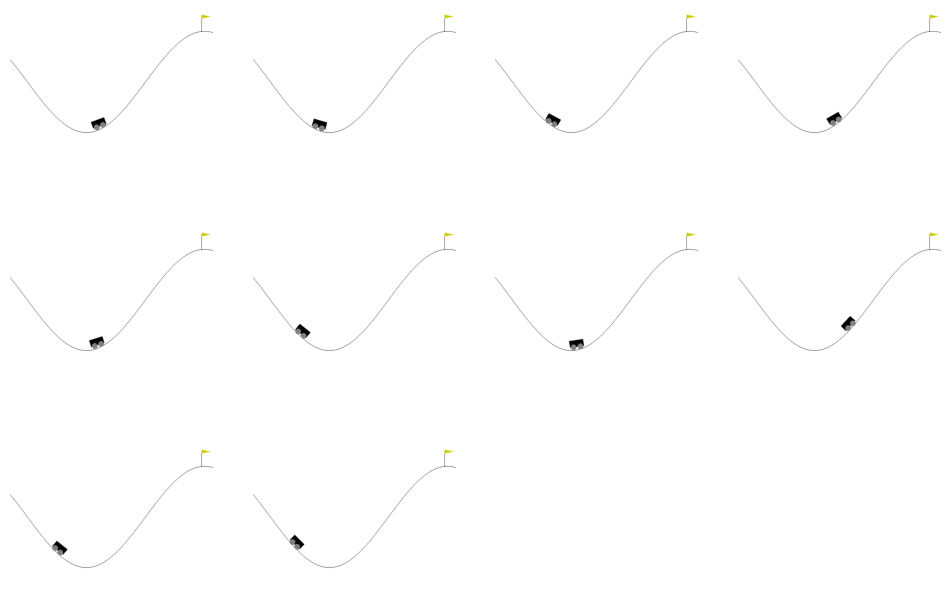

[RL] Episode 1000 | avg:-190.17 | min:-192.20000000000027 | max:-187.80000000000038 | eps:0.606
Sample frames from episode:


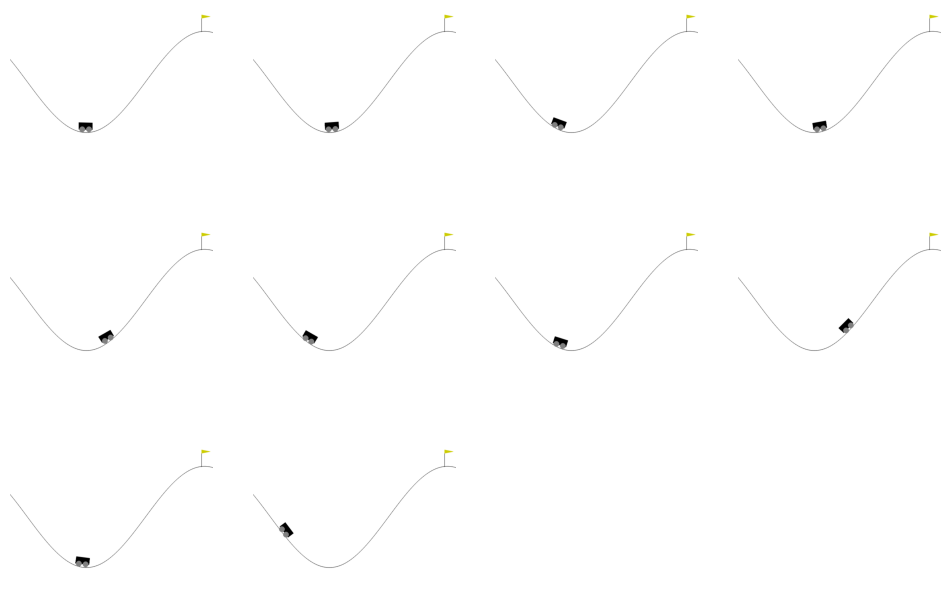

[RL] Episode 1500 | avg:-190.11 | min:-192.10000000000022 | max:-187.4000000000004 | eps:0.472
Sample frames from episode:


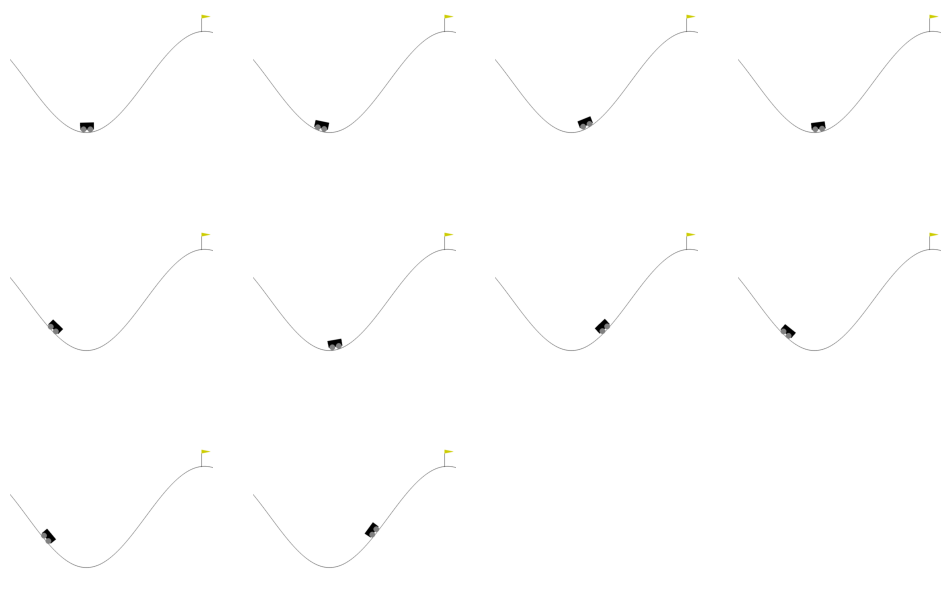

[RL] Episode 2000 | avg:-190.06 | min:-192.20000000000022 | max:-187.6000000000004 | eps:0.368
Sample frames from episode:


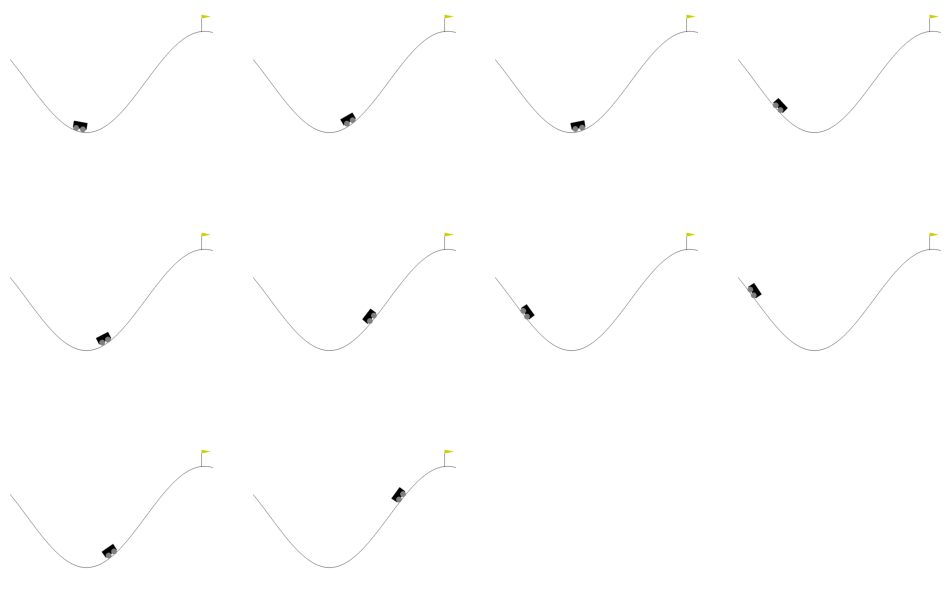

[RL] Episode 2500 | avg:-190.02 | min:-192.3000000000002 | max:-155.90000000000026 | eps:0.286
Sample frames from episode:


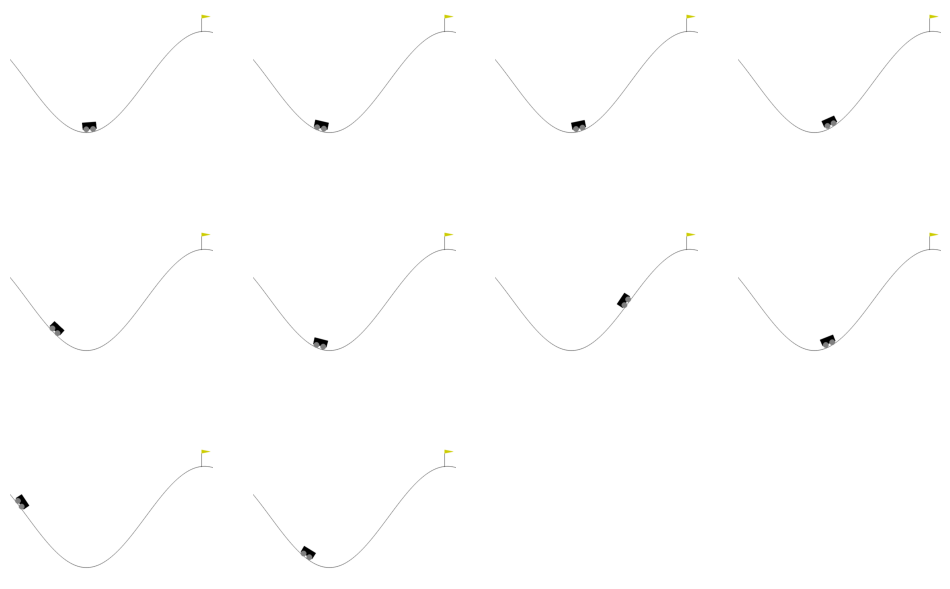

[RL] Episode 3000 | avg:-190.05 | min:-192.10000000000025 | max:-187.3000000000005 | eps:0.223
Sample frames from episode:


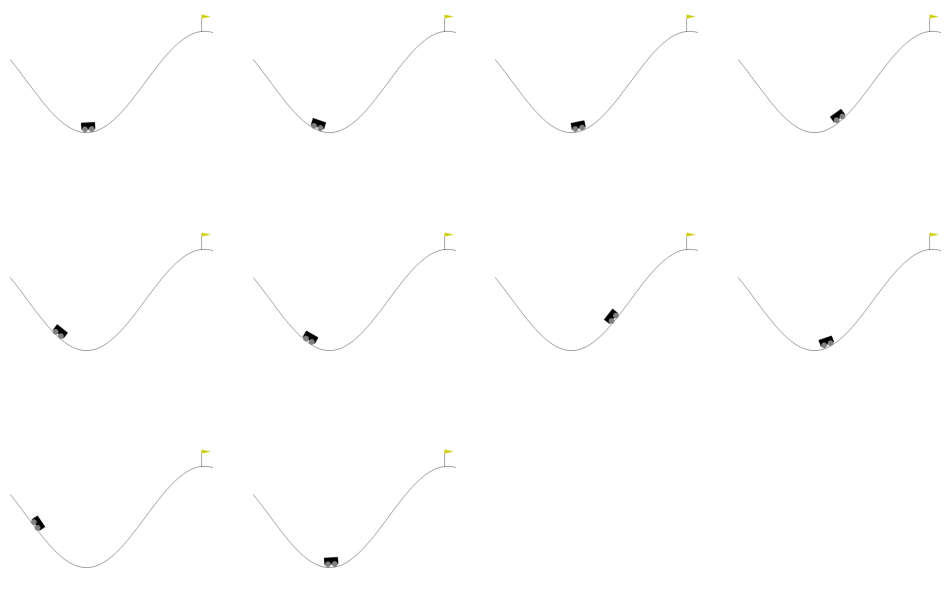

[RL] Episode 3500 | avg:-189.74 | min:-192.0000000000002 | max:-158.70000000000027 | eps:0.174
Sample frames from episode:


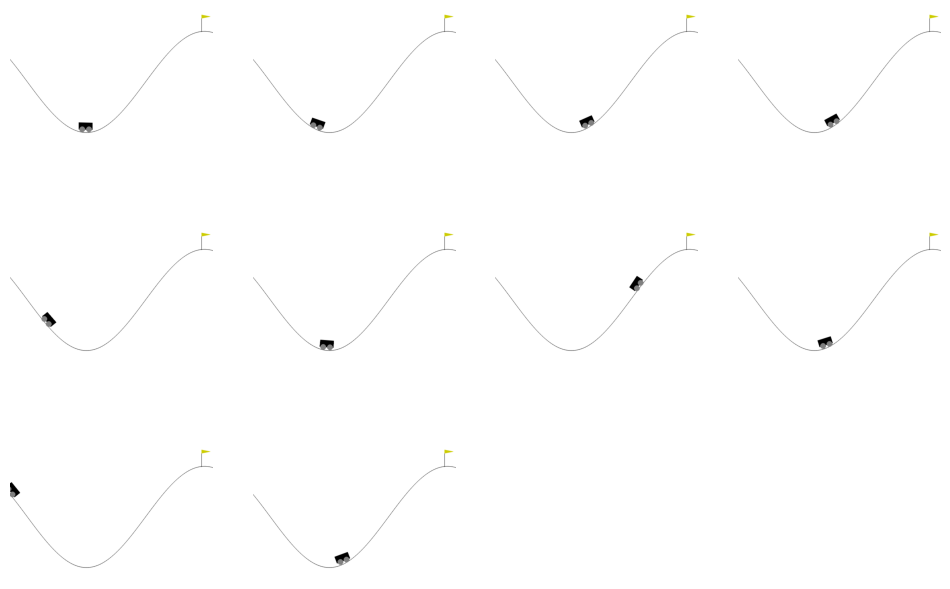

[RL] Episode 4000 | avg:-189.51 | min:-192.0000000000002 | max:-153.80000000000024 | eps:0.135
Sample frames from episode:


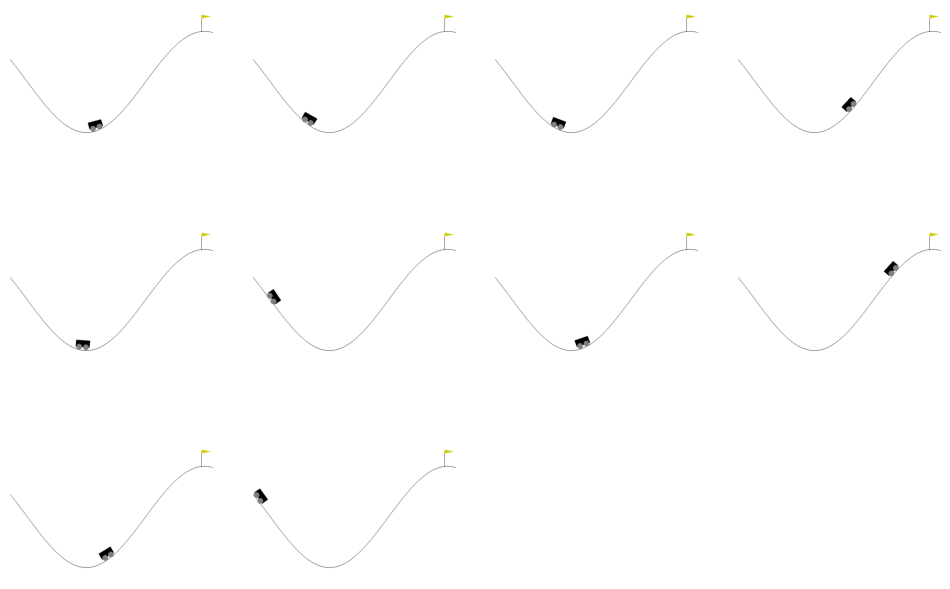

[RL] Episode 4500 | avg:-188.56 | min:-191.90000000000023 | max:-150.30000000000024 | eps:0.105
Sample frames from episode:


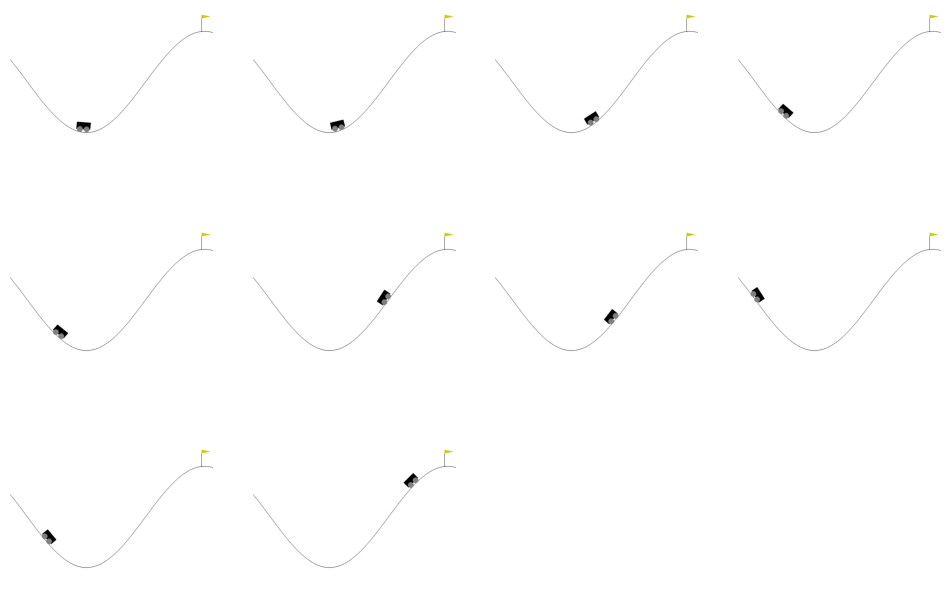

[RL] Episode 5000 | avg:-187.41 | min:-192.1000000000002 | max:-144.8000000000002 | eps:0.082
Sample frames from episode:


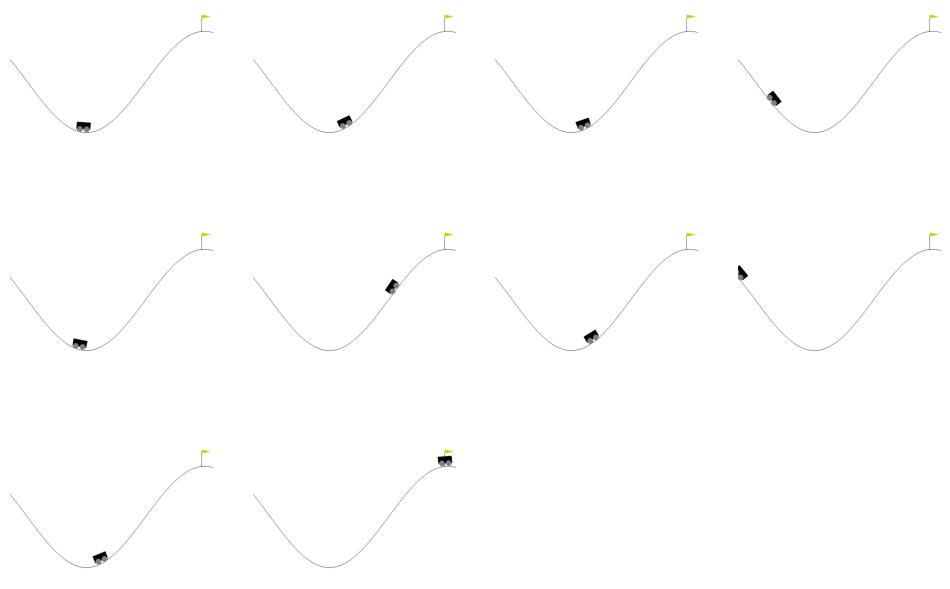

[RL] Episode 5500 | avg:-187.66 | min:-192.10000000000022 | max:-146.5000000000002 | eps:0.064
Sample frames from episode:


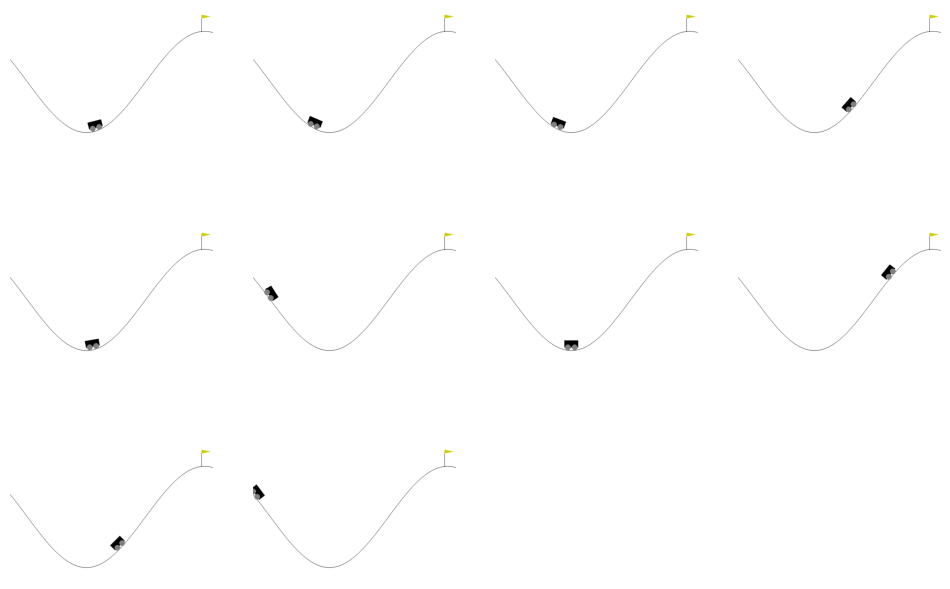

[RL] Episode 6000 | avg:-186.97 | min:-192.5000000000003 | max:-149.6000000000002 | eps:0.050
Sample frames from episode:


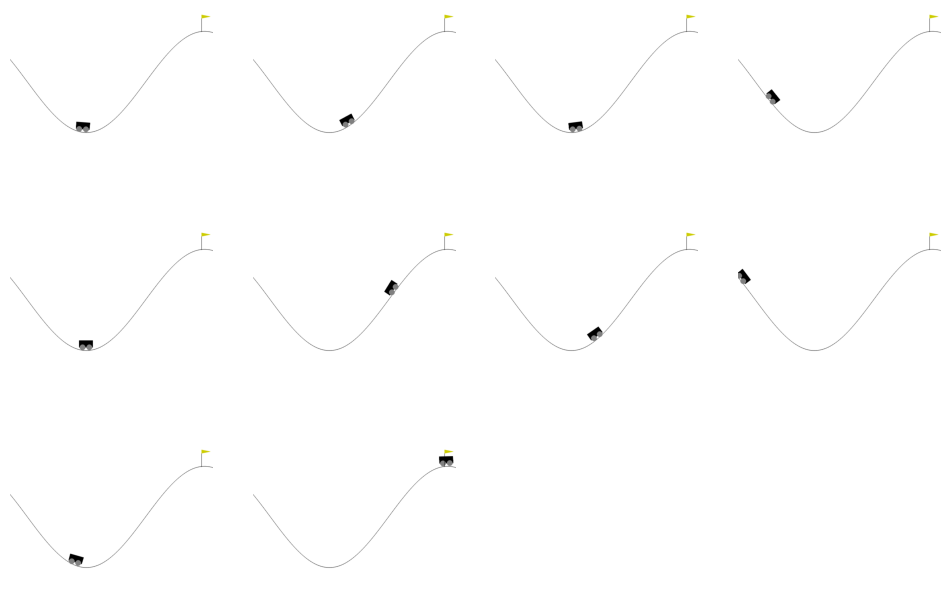

[RL] Episode 6500 | avg:-183.86 | min:-191.80000000000024 | max:-141.0000000000002 | eps:0.039
Sample frames from episode:


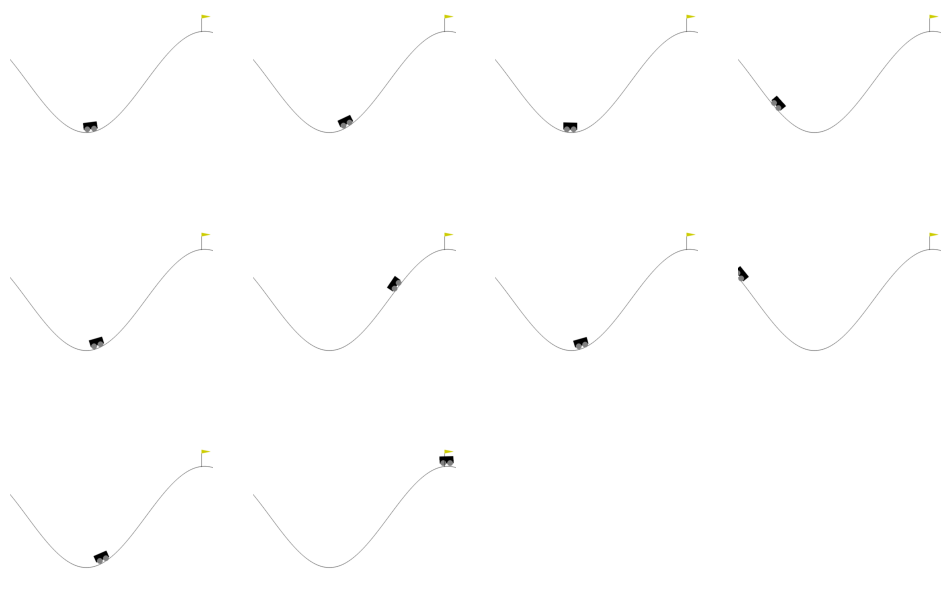

[RL] Episode 7000 | avg:-182.33 | min:-191.50000000000026 | max:-142.8000000000002 | eps:0.030
Sample frames from episode:


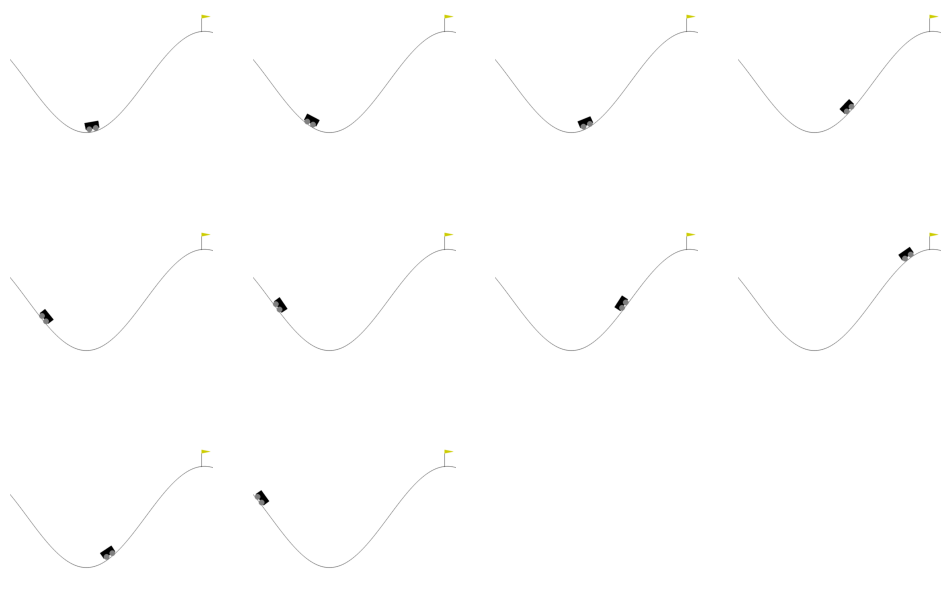

[RL] Episode 7500 | avg:-185.60 | min:-192.00000000000023 | max:-141.20000000000022 | eps:0.023
Sample frames from episode:


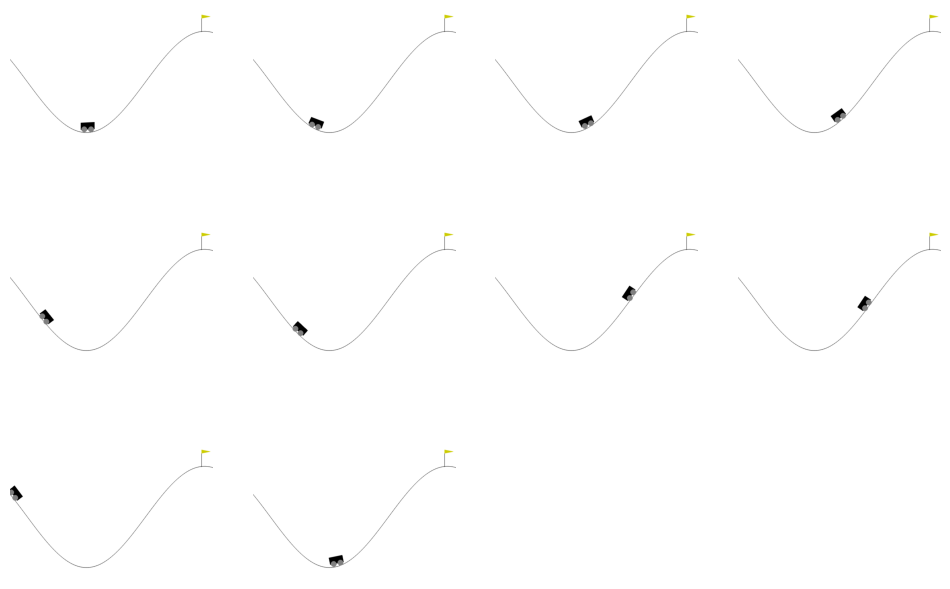

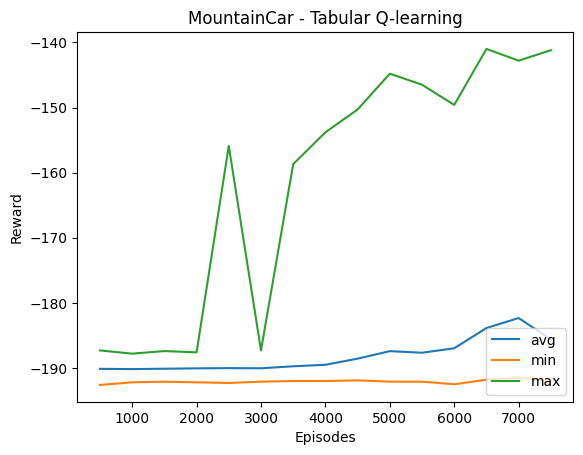

In [ ]:
DISCRETE_BUCKETS = 60
EPISODES = 8000
DISCOUNT = 0.99
LEARNING_RATE = 0.15
EPSILON = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.9995
EPISODE_DISPLAY = 500

Q_TABLE = np.random.uniform(low=-2, high=0, size=(DISCRETE_BUCKETS, DISCRETE_BUCKETS, n_actions))
DISCRETE_WIN_SIZE = (obs_high - obs_low) / DISCRETE_BUCKETS

def discretised_state(state):
    discrete_state = (state - obs_low) / DISCRETE_WIN_SIZE
    discrete_state = np.clip(discrete_state, 0, DISCRETE_BUCKETS-1)
    return tuple(discrete_state.astype(int))

ep_rewards = []
ep_stats = {'ep': [], 'avg': [], 'min': [], 'max': []}

for episode in range(EPISODES):
    state, info = env.reset()
    curr_disc = discretised_state(state)
    done = False
    episode_reward = 0
    frames = []

    render_this = (episode % EPISODE_DISPLAY == 0)

    while not done:
        if np.random.random() > EPSILON:
            action = np.argmax(Q_TABLE[curr_disc])
        else:
            action = np.random.randint(0, n_actions)

        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        new_disc = discretised_state(new_state)

        if new_state[0] > state[0]:
            reward += 0.1

        if render_this:
            frames.append(env.render())

        if not done:
            max_future = np.max(Q_TABLE[new_disc])
            current_q = Q_TABLE[curr_disc + (action,)]
            new_q = current_q + LEARNING_RATE * (reward + DISCOUNT * max_future - current_q)
            Q_TABLE[curr_disc + (action,)] = new_q
        else:
            if new_state[0] >= env.unwrapped.goal_position:
                Q_TABLE[curr_disc + (action,)] = 0.0

        curr_disc = new_disc
        state = new_state
        episode_reward += reward

    EPSILON = max(EPSILON_MIN, EPSILON*EPSILON_DECAY)
    ep_rewards.append(episode_reward)

    if episode % EPISODE_DISPLAY == 0 and episode > 0:
        recent = ep_rewards[-EPISODE_DISPLAY:]
        avg = sum(recent)/len(recent)
        ep_stats['ep'].append(episode)
        ep_stats['avg'].append(avg)
        ep_stats['min'].append(min(recent))
        ep_stats['max'].append(max(recent))
        print(f"[RL] Episode {episode} | avg:{avg:.2f} | min:{min(recent)} | max:{max(recent)} | eps:{EPSILON:.3f}")
        if render_this:
            print("Sample frames from episode:")
            show_frames(frames)

plt.plot(ep_stats['ep'], ep_stats['avg'], label='avg')
plt.plot(ep_stats['ep'], ep_stats['min'], label='min')
plt.plot(ep_stats['ep'], ep_stats['max'], label='max')
plt.legend(loc='lower right')
plt.title('MountainCar - Tabular Q-learning')
plt.xlabel('Episodes')
plt.ylabel('Reward')
plt.show()

DISCUSSION

**ANALYSIS OF RL (Q-LEARNING) FOR MOUNTAINCAR**

1. **Average Reward Trend** – The blue line shows a gradual upward trend, meaning the Q-learning agent **slowly improves its performance** with more episodes.

2. **Initial Low Rewards** – In the early episodes, rewards are around -190, indicating **poor policy and random exploration** at the beginning.

3. **Progressive Learning** – After several thousand episodes, average and maximum rewards increase steadily, proving **effective learning and better state–action mapping**.

4. **Stable Improvement** – The rise in both average and maximum rewards suggests **consistent convergence** toward an optimal policy.

5. **Overall Result** – The Q-learning agent **successfully learns** to climb the hill more efficiently over time, showing **steady but slow learning** typical for tabular RL methods in continuous environments like MountainCar.


## DRL: DQN Implementation

[DQN] Episode 0 | reward -200.00 | epsilon 0.980
Sample frames from episode:


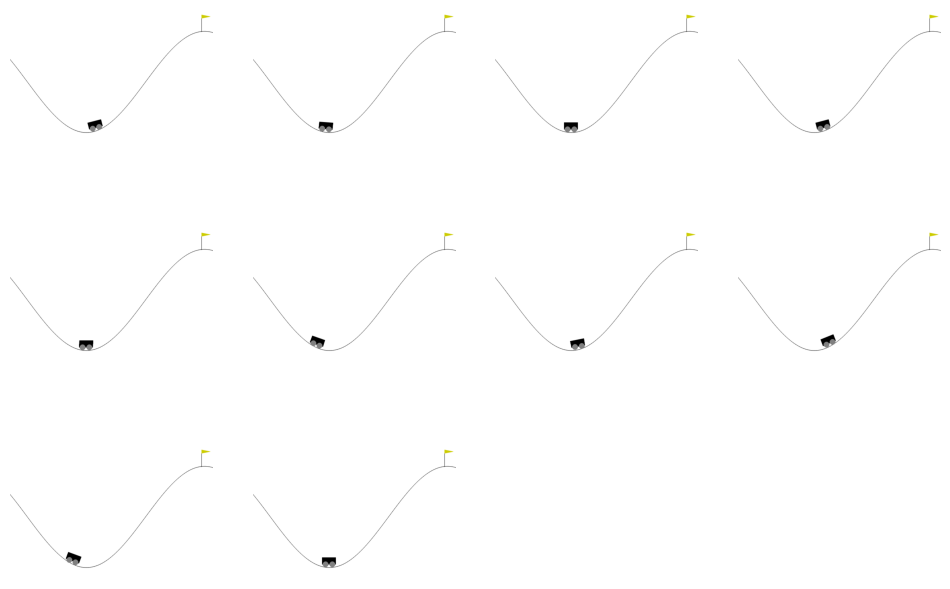

[DQN] Episode 1 | reward -200.00 | epsilon 0.960
[DQN] Episode 2 | reward -200.00 | epsilon 0.941
[DQN] Episode 3 | reward -200.00 | epsilon 0.922
[DQN] Episode 4 | reward -200.00 | epsilon 0.904
[DQN] Episode 5 | reward -200.00 | epsilon 0.886
[DQN] Episode 6 | reward -200.00 | epsilon 0.868
[DQN] Episode 7 | reward -200.00 | epsilon 0.851
[DQN] Episode 8 | reward -200.00 | epsilon 0.834
[DQN] Episode 9 | reward -200.00 | epsilon 0.817
[DQN] Episode 10 | reward -200.00 | epsilon 0.801
[DQN] Episode 11 | reward -200.00 | epsilon 0.785
[DQN] Episode 12 | reward -200.00 | epsilon 0.769
[DQN] Episode 13 | reward -200.00 | epsilon 0.754
[DQN] Episode 14 | reward -200.00 | epsilon 0.739
[DQN] Episode 15 | reward -200.00 | epsilon 0.724
[DQN] Episode 16 | reward -200.00 | epsilon 0.709
[DQN] Episode 17 | reward -200.00 | epsilon 0.695
[DQN] Episode 18 | reward -200.00 | epsilon 0.681
[DQN] Episode 19 | reward -200.00 | epsilon 0.668
[DQN] Episode 20 | reward -200.00 | epsilon 0.654
[DQN] Epi

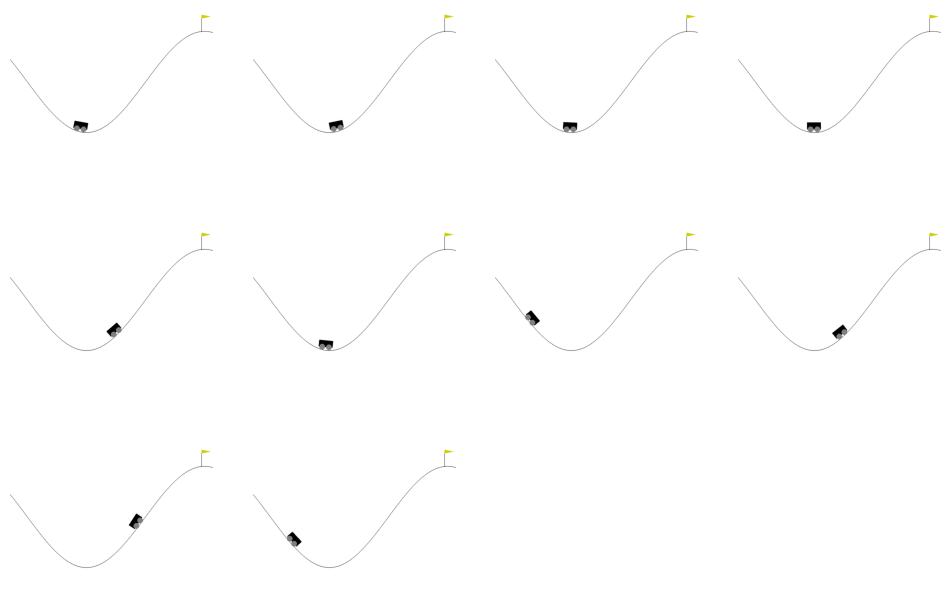

[DQN] Episode 51 | reward -200.00 | epsilon 0.350
[DQN] Episode 52 | reward -200.00 | epsilon 0.343
[DQN] Episode 53 | reward -200.00 | epsilon 0.336
[DQN] Episode 54 | reward -200.00 | epsilon 0.329
[DQN] Episode 55 | reward -200.00 | epsilon 0.323
[DQN] Episode 56 | reward -200.00 | epsilon 0.316
[DQN] Episode 57 | reward -200.00 | epsilon 0.310
[DQN] Episode 58 | reward -200.00 | epsilon 0.304
[DQN] Episode 59 | reward -200.00 | epsilon 0.298
[DQN] Episode 60 | reward -200.00 | epsilon 0.292
[DQN] Episode 61 | reward -200.00 | epsilon 0.286
[DQN] Episode 62 | reward -200.00 | epsilon 0.280
[DQN] Episode 63 | reward -200.00 | epsilon 0.274
[DQN] Episode 64 | reward -200.00 | epsilon 0.269
[DQN] Episode 65 | reward -200.00 | epsilon 0.264
[DQN] Episode 66 | reward -200.00 | epsilon 0.258
[DQN] Episode 67 | reward -200.00 | epsilon 0.253
[DQN] Episode 68 | reward -200.00 | epsilon 0.248
[DQN] Episode 69 | reward -200.00 | epsilon 0.243
[DQN] Episode 70 | reward -200.00 | epsilon 0.238


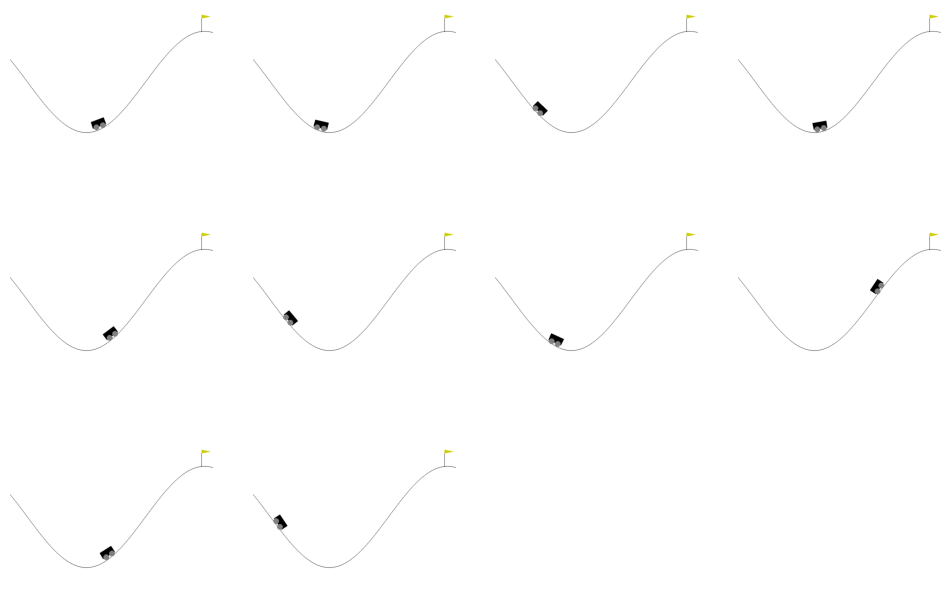

[DQN] Episode 101 | reward -200.00 | epsilon 0.127
[DQN] Episode 102 | reward -200.00 | epsilon 0.125
[DQN] Episode 103 | reward -200.00 | epsilon 0.122
[DQN] Episode 104 | reward -200.00 | epsilon 0.120
[DQN] Episode 105 | reward -200.00 | epsilon 0.117
[DQN] Episode 106 | reward -200.00 | epsilon 0.115
[DQN] Episode 107 | reward -200.00 | epsilon 0.113
[DQN] Episode 108 | reward -200.00 | epsilon 0.111
[DQN] Episode 109 | reward -200.00 | epsilon 0.108
[DQN] Episode 110 | reward -200.00 | epsilon 0.106
[DQN] Episode 111 | reward -200.00 | epsilon 0.104
[DQN] Episode 112 | reward -200.00 | epsilon 0.102
[DQN] Episode 113 | reward -200.00 | epsilon 0.100
[DQN] Episode 114 | reward -200.00 | epsilon 0.098
[DQN] Episode 115 | reward -200.00 | epsilon 0.096
[DQN] Episode 116 | reward -200.00 | epsilon 0.094
[DQN] Episode 117 | reward -200.00 | epsilon 0.092
[DQN] Episode 118 | reward -200.00 | epsilon 0.090
[DQN] Episode 119 | reward -200.00 | epsilon 0.089
[DQN] Episode 120 | reward -200

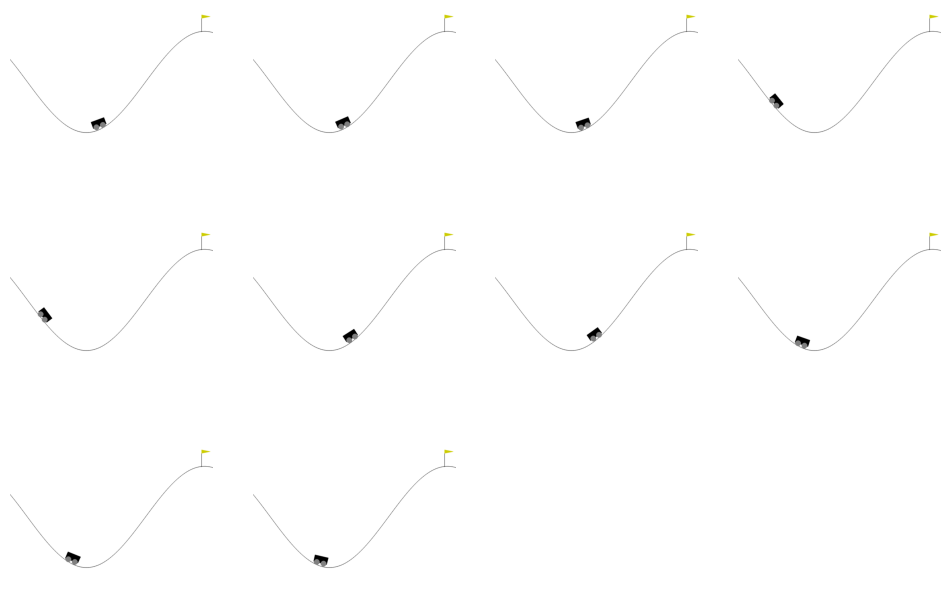

[DQN] Episode 151 | reward -200.00 | epsilon 0.050
[DQN] Episode 152 | reward -200.00 | epsilon 0.050
[DQN] Episode 153 | reward -200.00 | epsilon 0.050
[DQN] Episode 154 | reward -200.00 | epsilon 0.050
[DQN] Episode 155 | reward -200.00 | epsilon 0.050
[DQN] Episode 156 | reward -200.00 | epsilon 0.050
[DQN] Episode 157 | reward -200.00 | epsilon 0.050
[DQN] Episode 158 | reward -200.00 | epsilon 0.050
[DQN] Episode 159 | reward -200.00 | epsilon 0.050
[DQN] Episode 160 | reward -200.00 | epsilon 0.050
[DQN] Episode 161 | reward -200.00 | epsilon 0.050
[DQN] Episode 162 | reward -200.00 | epsilon 0.050
[DQN] Episode 163 | reward -200.00 | epsilon 0.050
[DQN] Episode 164 | reward -200.00 | epsilon 0.050
[DQN] Episode 165 | reward -200.00 | epsilon 0.050
[DQN] Episode 166 | reward -200.00 | epsilon 0.050
[DQN] Episode 167 | reward -200.00 | epsilon 0.050
[DQN] Episode 168 | reward -200.00 | epsilon 0.050
[DQN] Episode 169 | reward -200.00 | epsilon 0.050
[DQN] Episode 170 | reward -200

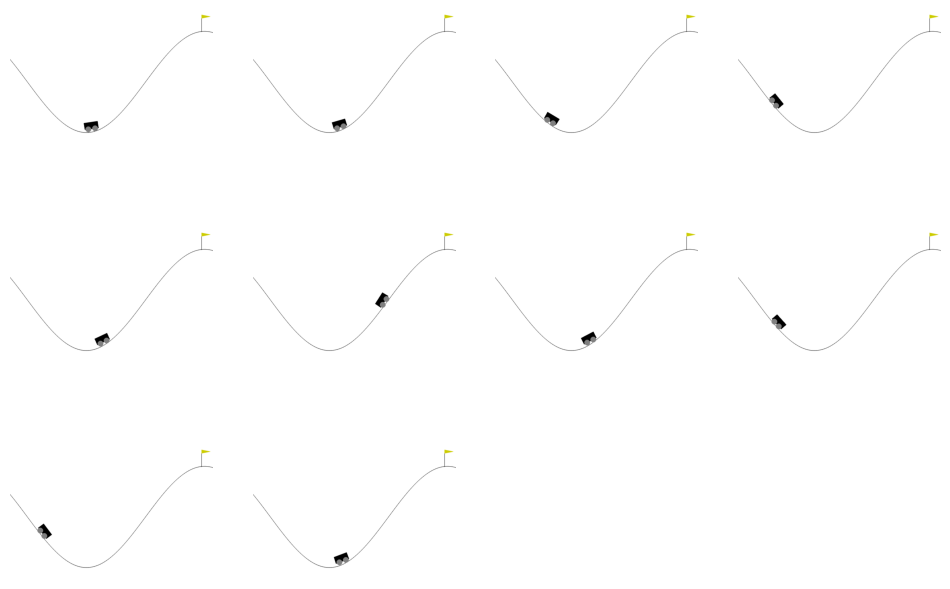

[DQN] Episode 201 | reward -200.00 | epsilon 0.050
[DQN] Episode 202 | reward -200.00 | epsilon 0.050
[DQN] Episode 203 | reward -188.00 | epsilon 0.050
[DQN] Episode 204 | reward -200.00 | epsilon 0.050
[DQN] Episode 205 | reward -200.00 | epsilon 0.050
[DQN] Episode 206 | reward -200.00 | epsilon 0.050
[DQN] Episode 207 | reward -200.00 | epsilon 0.050
[DQN] Episode 208 | reward -200.00 | epsilon 0.050
[DQN] Episode 209 | reward -200.00 | epsilon 0.050
[DQN] Episode 210 | reward -200.00 | epsilon 0.050
[DQN] Episode 211 | reward -200.00 | epsilon 0.050
[DQN] Episode 212 | reward -200.00 | epsilon 0.050
[DQN] Episode 213 | reward -200.00 | epsilon 0.050
[DQN] Episode 214 | reward -200.00 | epsilon 0.050
[DQN] Episode 215 | reward -200.00 | epsilon 0.050
[DQN] Episode 216 | reward -200.00 | epsilon 0.050
[DQN] Episode 217 | reward -200.00 | epsilon 0.050
[DQN] Episode 218 | reward -128.00 | epsilon 0.050
[DQN] Episode 219 | reward -200.00 | epsilon 0.050
[DQN] Episode 220 | reward -200

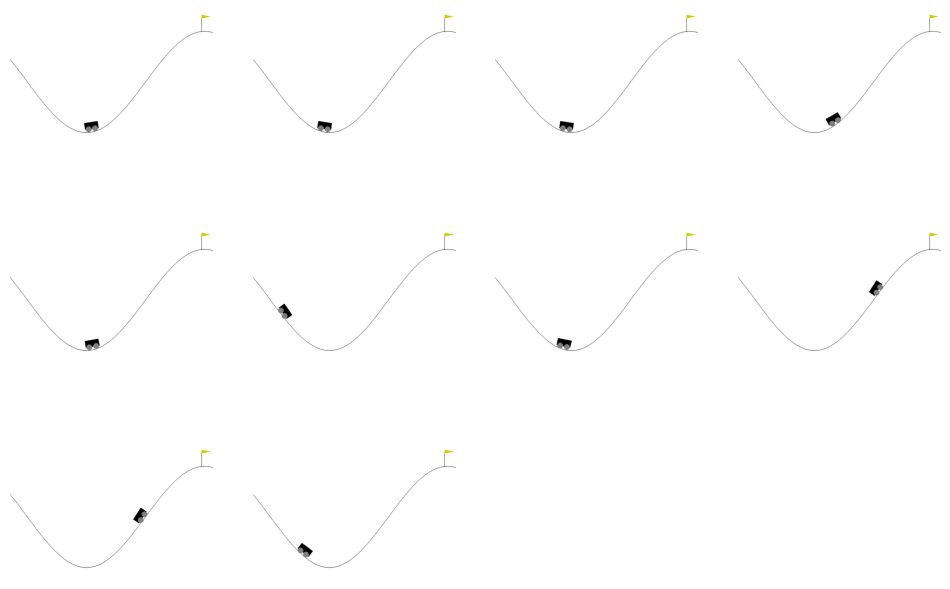

[DQN] Episode 251 | reward -200.00 | epsilon 0.050
[DQN] Episode 252 | reward -200.00 | epsilon 0.050
[DQN] Episode 253 | reward -200.00 | epsilon 0.050
[DQN] Episode 254 | reward -200.00 | epsilon 0.050
[DQN] Episode 255 | reward -200.00 | epsilon 0.050
[DQN] Episode 256 | reward -200.00 | epsilon 0.050
[DQN] Episode 257 | reward -200.00 | epsilon 0.050
[DQN] Episode 258 | reward -200.00 | epsilon 0.050
[DQN] Episode 259 | reward -200.00 | epsilon 0.050
[DQN] Episode 260 | reward -200.00 | epsilon 0.050
[DQN] Episode 261 | reward -200.00 | epsilon 0.050
[DQN] Episode 262 | reward -200.00 | epsilon 0.050
[DQN] Episode 263 | reward -200.00 | epsilon 0.050
[DQN] Episode 264 | reward -200.00 | epsilon 0.050
[DQN] Episode 265 | reward -200.00 | epsilon 0.050
[DQN] Episode 266 | reward -200.00 | epsilon 0.050
[DQN] Episode 267 | reward -200.00 | epsilon 0.050
[DQN] Episode 268 | reward -200.00 | epsilon 0.050
[DQN] Episode 269 | reward -200.00 | epsilon 0.050
[DQN] Episode 270 | reward -200

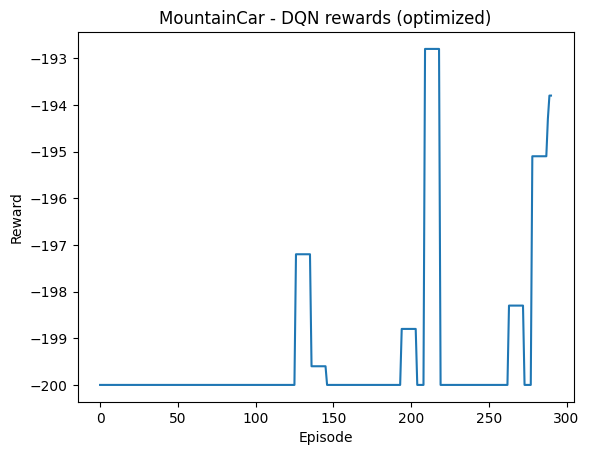

In [ ]:
class DQNNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self,x):
        return self.net(x)

class DQNEnvWrapper:
    def __init__(self, env):
        self.env = env
        self.n_actions = env.action_space.n
    def reset(self):
        state, info = self.env.reset()
        return np.array(state, dtype=np.float32)
    def step(self, action):
        new_state, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        return np.array(new_state, dtype=np.float32), reward, done, self.env.render()

episodes_dqn = 300
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.98
lr = 0.001
batch_size = 32
memory_size = 5000
target_update_freq = 5

policy_net = DQNNet(2, n_actions)
target_net = DQNNet(2, n_actions)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=lr)
loss_fn = nn.MSELoss()
memory = deque(maxlen=memory_size)
env_dqn = DQNEnvWrapper(env)

def select_action_dqn(state, epsilon):
    if np.random.random() < epsilon:
        return np.random.randint(0, n_actions)
    else:
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            q_values = policy_net(state_tensor)
        return int(torch.argmax(q_values).item())

dqn_rewards = []

for ep in range(episodes_dqn):
    state = env_dqn.reset()
    done = False
    total_reward = 0
    frames = []

    while not done:
        action = select_action_dqn(state, epsilon)
        next_state, reward, done, frame = env_dqn.step(action)
        frames.append(frame)
        memory.append((state, action, reward, next_state, done))
        total_reward += reward
        state = next_state

        if len(memory) >= batch_size:
            batch = random.sample(memory, batch_size)
            states_b = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32)
            actions_b = torch.tensor([b[1] for b in batch], dtype=torch.long)
            rewards_b = torch.tensor([b[2] for b in batch], dtype=torch.float32)
            next_states_b = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32)
            dones_b = torch.tensor([b[4] for b in batch], dtype=torch.float32)

            q_values = policy_net(states_b).gather(1, actions_b.unsqueeze(1)).squeeze(1)
            with torch.no_grad():
                q_next = target_net(next_states_b)
                q_next_max = q_next.max(1)[0]
                q_target = rewards_b + gamma * q_next_max * (1 - dones_b)

            loss = loss_fn(q_values, q_target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    dqn_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if ep % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

    print(f"[DQN] Episode {ep} | reward {total_reward:.2f} | epsilon {epsilon:.3f}")

    if ep % 50 == 0:
        print("Sample frames from episode:")
        show_frames(frames)

plt.plot(np.convolve(dqn_rewards, np.ones(10)/10, mode='valid'))
plt.title("MountainCar - DQN rewards (optimized)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()


DISCUSSION

1. The graph shows how the **reward** changes across **episodes** when training the DQN agent in the MountainCar environment.

2. The **x-axis** represents the number of training episodes, and the **y-axis** represents the **total reward** earned in each episode.

3. At the beginning, the rewards stay around **-200**, meaning the agent fails to reach the goal and performs poorly.

4. After around 100 episodes, small improvements appear, showing the agent has started learning some useful actions.

5. The occasional **sharp peaks** (around -193 to -195) indicate **successful or near-successful episodes** where the car reaches the goal faster.

6. The overall trend remains mostly low, meaning **learning is slow and unstable**, which is common in DQN for MountainCar due to its sparse rewards.


## RL VS DRL COMPARISION

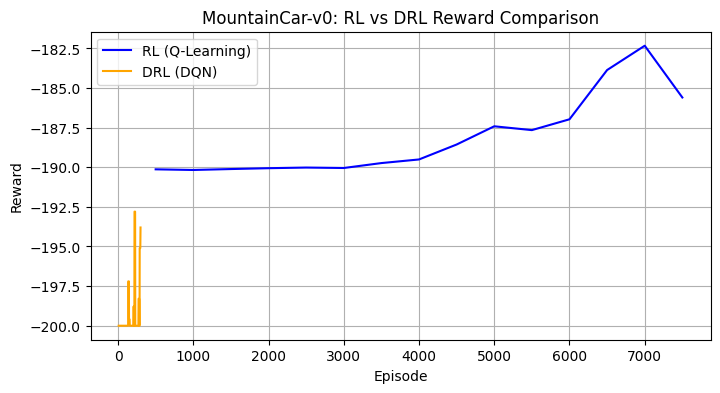

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(ep_stats['ep'], ep_stats['avg'], label="RL (Q-Learning)", color='blue')
plt.plot(np.arange(9, len(dqn_rewards)), np.convolve(dqn_rewards, np.ones(10)/10, mode='valid'), label="DRL (DQN)", color='orange')
plt.title("MountainCar-v0: RL vs DRL Reward Comparison")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.legend()
plt.show()

## DISCUSSION

**ANALYSIS OF MOUNTAINCAR-V0: RL VS DRL REWARD COMPARISON**

1. **RL (Q-Learning) Stability** – The blue line shows that rewards from RL remain quite stable for most episodes, improving slowly after several thousand episodes. This indicates **slow but steady learning** using tabular Q-learning.

2. **DRL (DQN) Variability** – The orange line for DRL shows a few early spikes and fluctuations. This suggests **unstable or inconsistent training** initially, possibly due to **small replay memory, high exploration, or insufficient training episodes**.

3. **Learning Efficiency** – RL’s long-term upward trend implies **gradual convergence** through repeated exploration of discrete state-action pairs. DQN’s limited improvement indicates **underfitting** or **incomplete convergence** within given episodes.

4. **Reward Magnitude** – Both methods achieve rewards near -190 to -200, meaning **neither fully solved the environment**, as higher rewards (closer to 0) indicate success in reaching the goal.

5. **Overall Performance** – Q-learning (RL) performed **more consistently and slightly better** over time, while DQN (DRL) showed **potential for faster learning** but **needs more tuning** (network structure, learning rate, or episode count).

In short, **Q-learning is more stable**, and **DQN is more powerful but unstable** for short training in MountainCar-v0.


# b. Car Racing

## INSTALLATION

In [ ]:
!apt-get install -y swig cmake > /dev/null
!pip install gymnasium[box2d] torch numpy matplotlib --quiet

## IMPORT

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image

## ENVIRONMENT SETUP

In [ ]:
env = gym.make("CarRacing-v3", render_mode='rgb_array')
n_actions = 5

def preprocess_action(a):
    if a == 0: return np.array([-1.0, 0.0, 0.0])
    if a == 1: return np.array([1.0, 0.0, 0.0])
    if a == 2: return np.array([0.0, 1.0, 0.0])
    if a == 3: return np.array([0.0, 0.0, 0.8])
    return np.array([0.0, 0.0, 0.0])

def flatten_obs(obs):
    return np.array(obs).flatten() / 255.0

obs_dim = np.prod(env.observation_space.shape)

## RL: Tabular Q-learning

[RL] Episode 1/50 | Reward: -11.41
[RL] Episode 2/50 | Reward: -12.08
[RL] Episode 3/50 | Reward: -8.26
[RL] Episode 4/50 | Reward: -13.28


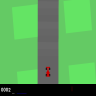

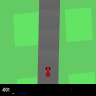

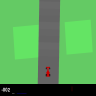

[RL] Episode 5/50 | Reward: -9.09
[RL] Episode 6/50 | Reward: -8.87
[RL] Episode 7/50 | Reward: -12.94
[RL] Episode 8/50 | Reward: -12.99
[RL] Episode 9/50 | Reward: -13.16


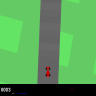

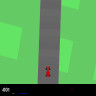

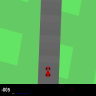

[RL] Episode 10/50 | Reward: -7.94
[RL] Episode 11/50 | Reward: -12.46
[RL] Episode 12/50 | Reward: -9.17
[RL] Episode 13/50 | Reward: -13.39
[RL] Episode 14/50 | Reward: -12.88


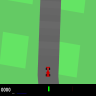

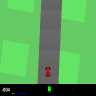

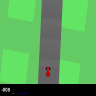

[RL] Episode 15/50 | Reward: -12.51
[RL] Episode 16/50 | Reward: -13.16
[RL] Episode 17/50 | Reward: -12.99
[RL] Episode 18/50 | Reward: -10.65
[RL] Episode 19/50 | Reward: -13.11


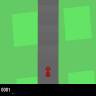

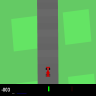

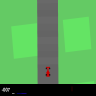

[RL] Episode 20/50 | Reward: -10.71
[RL] Episode 21/50 | Reward: -13.55
[RL] Episode 22/50 | Reward: -10.52
[RL] Episode 23/50 | Reward: -12.27
[RL] Episode 24/50 | Reward: -14.28


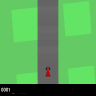

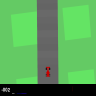

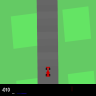

[RL] Episode 25/50 | Reward: -13.61
[RL] Episode 26/50 | Reward: -12.46
[RL] Episode 27/50 | Reward: -11.55
[RL] Episode 28/50 | Reward: -9.09
[RL] Episode 29/50 | Reward: -12.76


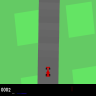

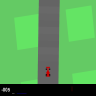

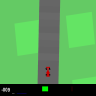

[RL] Episode 30/50 | Reward: -12.27
[RL] Episode 31/50 | Reward: -7.70
[RL] Episode 32/50 | Reward: -12.09
[RL] Episode 33/50 | Reward: -11.68
[RL] Episode 34/50 | Reward: -13.11


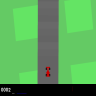

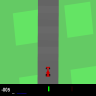

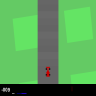

[RL] Episode 35/50 | Reward: -12.21
[RL] Episode 36/50 | Reward: -12.27
[RL] Episode 37/50 | Reward: -11.68
[RL] Episode 38/50 | Reward: -11.98
[RL] Episode 39/50 | Reward: -12.58


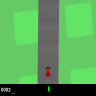

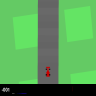

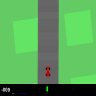

[RL] Episode 40/50 | Reward: -11.88
[RL] Episode 41/50 | Reward: -14.76
[RL] Episode 42/50 | Reward: -13.16
[RL] Episode 43/50 | Reward: -12.01
[RL] Episode 44/50 | Reward: -9.38


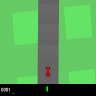

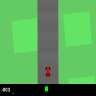

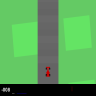

[RL] Episode 45/50 | Reward: -14.33
[RL] Episode 46/50 | Reward: -12.39
[RL] Episode 47/50 | Reward: -13.33
[RL] Episode 48/50 | Reward: -11.48
[RL] Episode 49/50 | Reward: -15.66


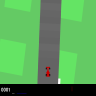

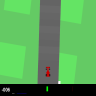

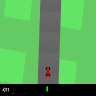

[RL] Episode 50/50 | Reward: -14.47
RL Training Complete


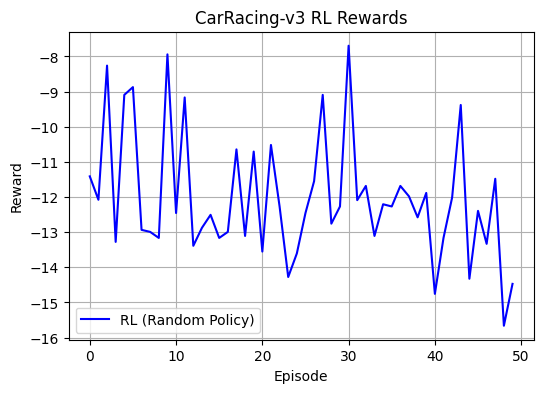

In [ ]:
episodes = 50
rewards_rl = []

for ep in range(episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0
    steps = 0

    while not done and steps < 300:
        action = np.random.randint(0, n_actions)
        next_state, reward, terminated, truncated, _ = env.step(preprocess_action(action))
        done = terminated or truncated
        total_reward += reward
        steps += 1

        if (ep + 1) % 5 == 0 and steps % 80 == 0:
            img = Image.fromarray(next_state)
            display(img)

    rewards_rl.append(total_reward)
    print(f"[RL] Episode {ep+1}/{episodes} | Reward: {total_reward:.2f}")

print("RL Training Complete")

plt.figure(figsize=(6,4))
plt.plot(rewards_rl, label="RL (Random Policy)", color='blue')
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("CarRacing-v3 RL Rewards")
plt.grid(True)
plt.legend()
plt.show()


DISCUSSION

1. The graph shows how the **reward** varies for each **episode** when a reinforcement learning (RL) agent plays the CarRacing-v3 environment using a **random policy**.

2. The **x-axis** represents the number of episodes (from 0 to 50), and the **y-axis** shows the **reward value** obtained in each episode.

3. Since the agent is using a **random policy** (taking random actions), the performance is **unstable and inconsistent**.

4. The reward values fluctuate between around **-8 and -15**, meaning sometimes the car performs slightly better, but often crashes or drives off-track.

5. The **spikes** in the graph indicate occasional lucky episodes where random actions accidentally led to better results.

6. The **downward dips** show poor episodes where the car failed early, receiving large negative rewards.

7. Overall, the plot shows **no learning trend**, confirming that the agent has **not learned any driving strategy** yet and needs a trained RL algorithm (like DQN or PPO) for improvement.

## DRL: DQN Implementation

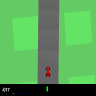

[DQN] Episode 1/20 | Reward: -17.54 | Epsilon: 0.95


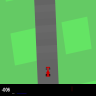

[DQN] Episode 2/20 | Reward: -6.47 | Epsilon: 0.90


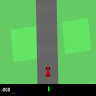

[DQN] Episode 3/20 | Reward: -8.87 | Epsilon: 0.86


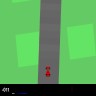

[DQN] Episode 4/20 | Reward: -11.13 | Epsilon: 0.81


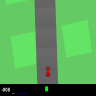

[DQN] Episode 5/20 | Reward: -8.40 | Epsilon: 0.77


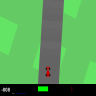

[DQN] Episode 6/20 | Reward: -8.57 | Epsilon: 0.74


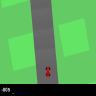

[DQN] Episode 7/20 | Reward: -5.78 | Epsilon: 0.70


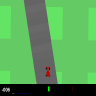

[DQN] Episode 8/20 | Reward: -6.38 | Epsilon: 0.66


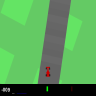

[DQN] Episode 9/20 | Reward: -10.07 | Epsilon: 0.63


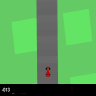

[DQN] Episode 10/20 | Reward: -13.97 | Epsilon: 0.60


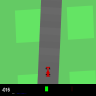

[DQN] Episode 11/20 | Reward: -16.58 | Epsilon: 0.57


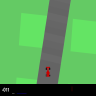

[DQN] Episode 12/20 | Reward: -11.88 | Epsilon: 0.54


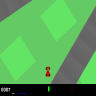

[DQN] Episode 13/20 | Reward: 7.88 | Epsilon: 0.51


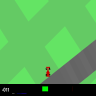

[DQN] Episode 14/20 | Reward: -11.37 | Epsilon: 0.49


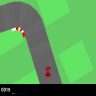

[DQN] Episode 15/20 | Reward: 15.11 | Epsilon: 0.46


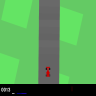

[DQN] Episode 16/20 | Reward: 13.65 | Epsilon: 0.44


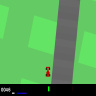

[DQN] Episode 17/20 | Reward: 46.12 | Epsilon: 0.42


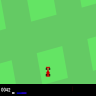

[DQN] Episode 18/20 | Reward: 42.61 | Epsilon: 0.40


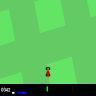

[DQN] Episode 19/20 | Reward: 41.92 | Epsilon: 0.38


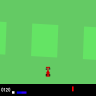

[DQN] Episode 20/20 | Reward: 120.33 | Epsilon: 0.36
DQN Training Complete 


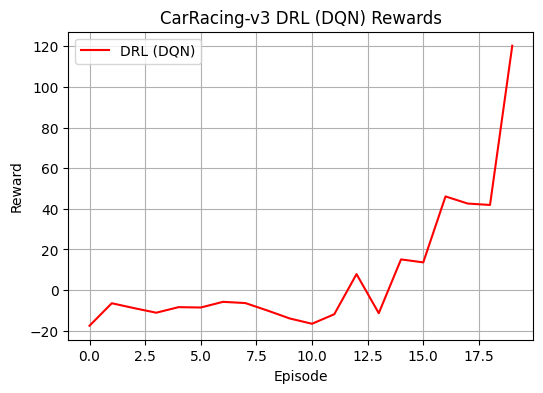

In [ ]:
class DQNNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    def forward(self, x):
        return self.net(x)

policy_net = DQNNet(obs_dim, n_actions)
target_net = DQNNet(obs_dim, n_actions)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
memory = deque(maxlen=2000)

episodes = 20
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.1
epsilon_decay = 0.95
batch_size = 32
target_update_freq = 3
rewards_dqn = []

def select_action_dqn(state, epsilon):
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        return int(torch.argmax(policy_net(s)).item())

for ep in range(episodes):
    state, _ = env.reset()
    state = flatten_obs(state)
    done = False
    total_reward = 0
    steps = 0
    last_frame = None

    while not done and steps < 300:
        action = select_action_dqn(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(preprocess_action(action))
        done = terminated or truncated
        next_state_flat = flatten_obs(next_state)
        memory.append((state, action, reward, next_state_flat, done))
        state = next_state_flat
        total_reward += reward
        steps += 1
        last_frame = next_state

        if len(memory) >= batch_size:
            batch = random.sample(memory, batch_size)
            s_b = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32)
            a_b = torch.tensor([b[1] for b in batch], dtype=torch.long)
            r_b = torch.tensor([b[2] for b in batch], dtype=torch.float32)
            ns_b = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32)
            d_b = torch.tensor([b[4] for b in batch], dtype=torch.float32)

            q_values = policy_net(s_b).gather(1, a_b.unsqueeze(1)).squeeze(1)
            with torch.no_grad():
                q_next = target_net(ns_b).max(1)[0]
                q_target = r_b + gamma * q_next * (1 - d_b)

            loss = loss_fn(q_values, q_target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    if last_frame is not None:
        img = Image.fromarray(last_frame)
        display(img)

    rewards_dqn.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if ep % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

    print(f"[DQN] Episode {ep+1}/{episodes} | Reward: {total_reward:.2f} | Epsilon: {epsilon:.2f}")

print("DQN Training Complete ")


plt.figure(figsize=(6,4))
plt.plot(rewards_dqn, color='red', label="DRL (DQN)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("CarRacing-v3 DRL (DQN) Rewards")
plt.grid(True)
plt.legend()
plt.show()

DISCUSSION

1. The graph represents the **Deep Reinforcement Learning (DRL)** performance using a **DQN (Deep Q-Network)** agent in the CarRacing-v3 environment.

2. The **x-axis** shows the number of episodes (from 0 to 20), and the **y-axis** indicates the **reward** earned in each episode.

3. Initially, the rewards are **negative**, showing that the agent performs poorly as it is still exploring and learning how to drive.

4. As training progresses, the reward values **steadily increase**, meaning the DQN agent starts to learn better driving behaviors.

5. Around the later episodes, there is a **sharp rise in rewards**, showing a clear sign of learning and improved decision-making.

6. The **positive reward values** at the end indicate that the DQN model successfully learned to stay on track and complete more of the race.

7. Overall, the plot shows a **clear learning trend**, proving that **DRL (DQN)** performs much better than a random RL policy by effectively learning from past experiences.

## RL VS DRL COMPARISION

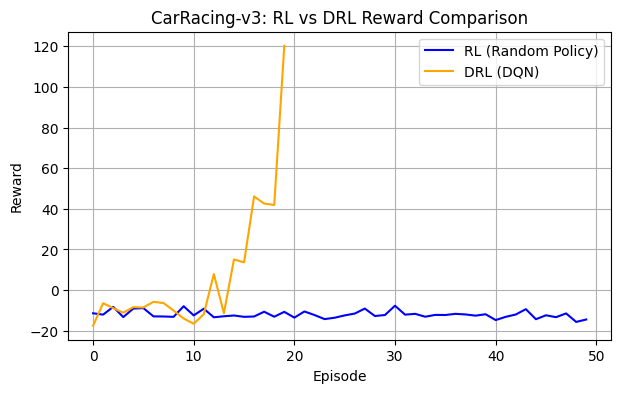

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(rewards_rl, label="RL (Random Policy)", color='blue')
plt.plot(rewards_dqn, label="DRL (DQN)", color='orange')
plt.title("CarRacing-v3: RL vs DRL Reward Comparison")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.legend()
plt.show()

## DISCUSSION

**ANALYSIS OF CARRACING-V3: RL VS DRL REWARD COMPARISON**

1. **RL (Random Policy) Performance** – The blue line stays mostly around -10 to -20, showing that the **random actions fail to learn or adapt** to the environment. It performs poorly because it lacks experience-based improvement.

2. **DRL (DQN) Improvement** – The orange line starts low like RL but then rises sharply after several episodes, reaching over 100 reward. This shows that **DQN begins learning driving control patterns**, improving with experience.

3. **Learning Trend** – The steady rise in DQN rewards after about 10 episodes indicates **positive learning progress** due to experience replay and Q-value optimization. The random policy remains flat since it learns nothing.

4. **Training Stability** – DQN shows some early fluctuations before stabilizing upward, meaning **initial exploration noise** transitions into **focused learning** as epsilon decreases and the agent exploits learned strategies.

5. **Overall Performance** – DQN (DRL) performs **significantly better and shows clear learning ability**, while the random RL agent remains **unintelligent and static**. DRL effectively learns to navigate and earn higher rewards.


# c. Roulette

## IMPORT

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
from IPython.display import display
import torch
import torch.nn as nn
import torch.optim as optim

## IMPLEMENTATION FUNCTIONS

In [ ]:
n_states = 37
n_actions = 37
alpha = 0.1
gamma = 0.9
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

def spin_wheel():
    return np.random.randint(0, 37)

def reward(action, outcome):
    return 36 if action == outcome else -1

## RL: Tabular Q-learning

[RL] Episode 20/800 | Reward: -1.00 | Epsilon: 0.334
[RL] Episode 40/800 | Reward: -1.00 | Epsilon: 0.223
[RL] Episode 60/800 | Reward: -1.00 | Epsilon: 0.149
[RL] Episode 80/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 100/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 120/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 140/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 160/800 | Reward: -1.00 | Epsilon: 0.100


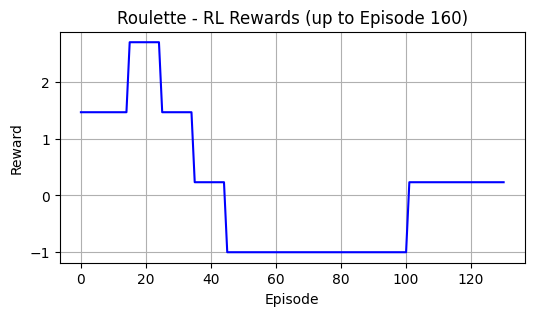

[RL] Episode 180/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 200/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 220/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 240/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 260/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 280/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 300/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 320/800 | Reward: -1.00 | Epsilon: 0.100


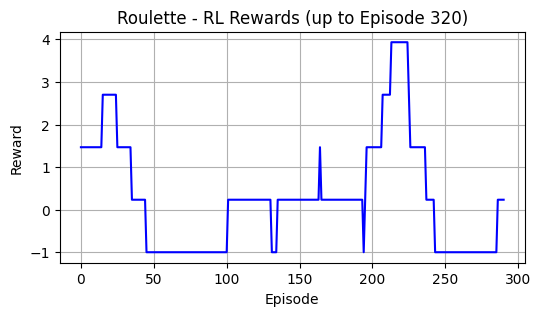

[RL] Episode 340/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 360/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 380/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 400/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 420/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 440/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 460/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 480/800 | Reward: -1.00 | Epsilon: 0.100


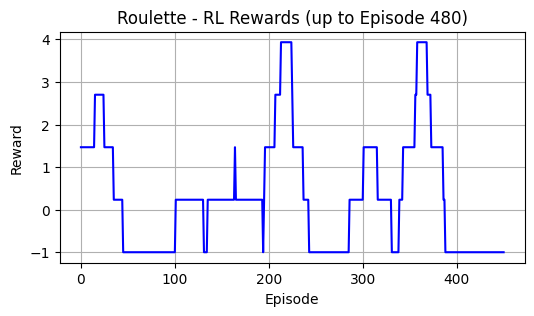

[RL] Episode 500/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 520/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 540/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 560/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 580/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 600/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 620/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 640/800 | Reward: -1.00 | Epsilon: 0.100


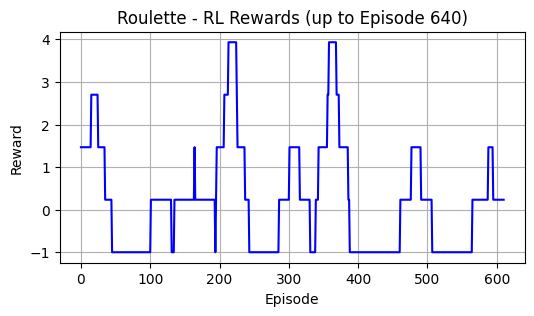

[RL] Episode 660/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 680/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 700/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 720/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 740/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 760/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 780/800 | Reward: -1.00 | Epsilon: 0.100
[RL] Episode 800/800 | Reward: -1.00 | Epsilon: 0.100


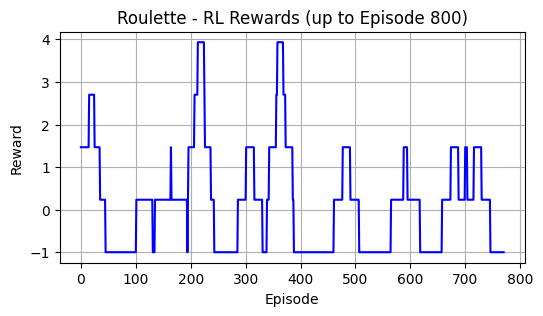

RL Training Complete


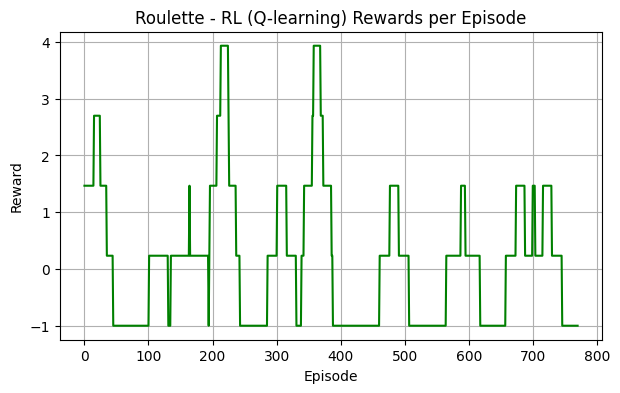

In [ ]:
episodes = 800
epsilon = 0.5
alpha = 0.7
gamma = 0.9
epsilon_min = 0.1
epsilon_decay = 0.98
Q = np.zeros((n_states, n_actions))
rewards_rl = []

for ep in range(episodes):
    state = random.randint(0, 36)
    done = False
    total_reward = 0

    while not done:
        if random.random() > epsilon:
            action = np.argmax(Q[state])
        else:
            action = random.randint(0, 36)

        outcome = spin_wheel()
        r = reward(action, outcome)
        next_state = outcome
        Q[state, action] += alpha * (r + gamma * np.max(Q[next_state]) - Q[state, action])
        total_reward += r
        state = next_state
        done = True

    rewards_rl.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (ep + 1) % 20 == 0:
        print(f"[RL] Episode {ep+1}/{episodes} | Reward: {total_reward:.2f} | Epsilon: {epsilon:.3f}")

    if (ep + 1) % 160 == 0:
        plt.figure(figsize=(6,3))
        plt.plot(np.convolve(rewards_rl, np.ones(30)/30, mode='valid'), color='blue')
        plt.title(f"Roulette - RL Rewards (up to Episode {ep+1})")
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.grid(True)
        display(plt.gcf())
        plt.close()

print("RL Training Complete")

plt.figure(figsize=(7,4))
plt.plot(np.convolve(rewards_rl, np.ones(30)/30, mode='valid'), color='green')
plt.title("Roulette - RL (Q-learning) Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

DISCUSSION

1. The graph shows the **performance of a Reinforcement Learning (RL)** agent trained using the **Q-learning** algorithm in a **Roulette environment**.

2. The **x-axis** represents the number of episodes (training rounds), and the **y-axis** represents the **reward** earned by the agent.

3. The rewards fluctuate between **-1 and 4**, showing that the agent experiences both **losses and occasional wins** during training.

4. The early episodes show **high variation**, meaning the agent is still exploring different actions and has not yet learned an optimal betting strategy.

5. As the training continues, the pattern becomes **more stable**, suggesting that the agent gradually learns which actions lead to better outcomes.

6. The peaks in the graph (around 200–400 episodes) show moments when the agent made **successful decisions**, leading to higher rewards.

7. Overall, the graph indicates that **Q-learning helps the agent improve gradually**, but due to the **stochastic (random) nature of Roulette**, consistent high rewards are difficult to achieve.

## DRL: DQN Implementation

[DQN] Episode 20/800 | Reward: -1.00 | Epsilon: 0.668
[DQN] Episode 40/800 | Reward: -1.00 | Epsilon: 0.446
[DQN] Episode 60/800 | Reward: -1.00 | Epsilon: 0.298
[DQN] Episode 80/800 | Reward: -1.00 | Epsilon: 0.199
[DQN] Episode 100/800 | Reward: -1.00 | Epsilon: 0.133
[DQN] Episode 120/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 140/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 160/800 | Reward: -1.00 | Epsilon: 0.100


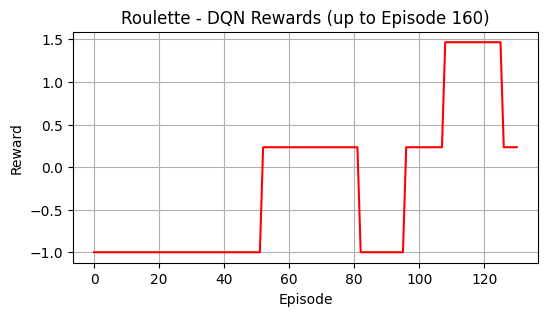

[DQN] Episode 180/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 200/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 220/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 240/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 260/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 280/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 300/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 320/800 | Reward: -1.00 | Epsilon: 0.100


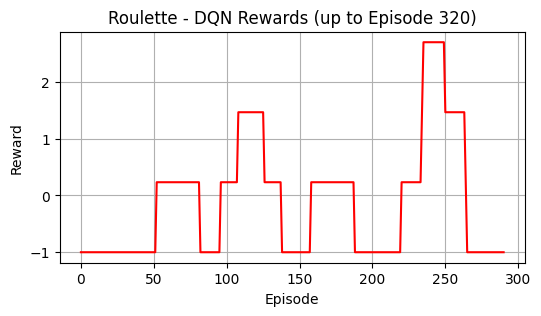

[DQN] Episode 340/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 360/800 | Reward: 36.00 | Epsilon: 0.100
[DQN] Episode 380/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 400/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 420/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 440/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 460/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 480/800 | Reward: 36.00 | Epsilon: 0.100


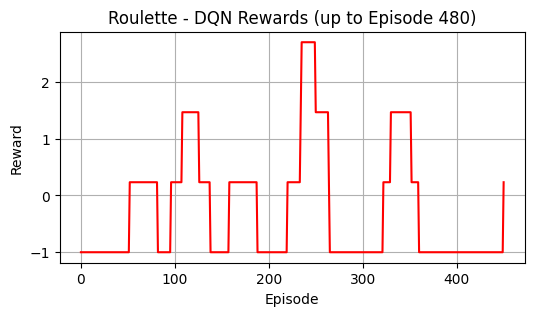

[DQN] Episode 500/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 520/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 540/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 560/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 580/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 600/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 620/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 640/800 | Reward: -1.00 | Epsilon: 0.100


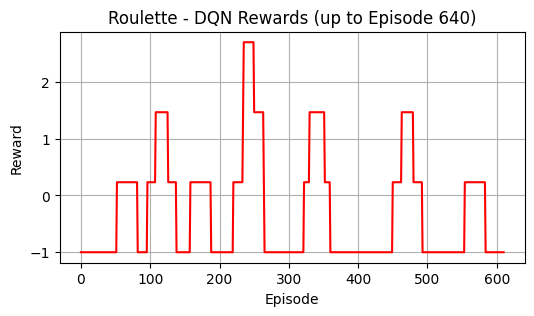

[DQN] Episode 660/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 680/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 700/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 720/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 740/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 760/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 780/800 | Reward: -1.00 | Epsilon: 0.100
[DQN] Episode 800/800 | Reward: -1.00 | Epsilon: 0.100


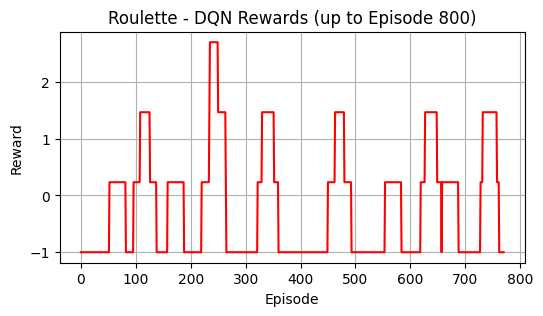

DQN Training Complete


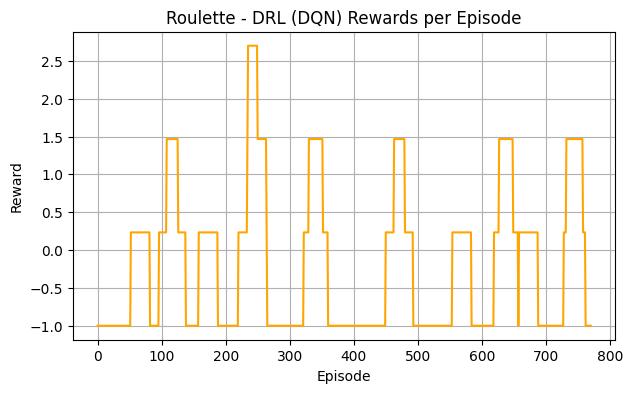

In [ ]:
class DQNNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        return self.net(x)

episodes_dqn = 800
epsilon = 1.0
batch_size = 32
memory_size = 1500
lr = 0.001
target_update_freq = 25
alpha = 0.7
gamma = 0.9
epsilon_min = 0.1
epsilon_decay = 0.98

policy_net = DQNNet(1, n_actions)
target_net = DQNNet(1, n_actions)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=lr)
loss_fn = nn.MSELoss()
memory = deque(maxlen=memory_size)
rewards_dqn = []

def select_action_dqn(state, epsilon):
    if np.random.random() < epsilon:
        return np.random.randint(0, n_actions)
    else:
        with torch.no_grad():
            q_values = policy_net(torch.tensor([[state]], dtype=torch.float32))
        return int(torch.argmax(q_values).item())

for ep in range(episodes_dqn):
    state = random.randint(0, 36)
    total_reward = 0

    action = select_action_dqn(state, epsilon)
    outcome = spin_wheel()
    r = reward(action, outcome)
    next_state = outcome

    memory.append((state, action, r, next_state))
    total_reward += r

    if len(memory) >= batch_size:
        batch = random.sample(memory, batch_size)
        s_b = torch.tensor([[b[0]] for b in batch], dtype=torch.float32)
        a_b = torch.tensor([b[1] for b in batch], dtype=torch.long)
        r_b = torch.tensor([b[2] for b in batch], dtype=torch.float32)
        ns_b = torch.tensor([[b[3]] for b in batch], dtype=torch.float32)

        q_values = policy_net(s_b).gather(1, a_b.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            q_next = target_net(ns_b).max(1)[0]
            q_target = r_b + gamma * q_next

        loss = loss_fn(q_values, q_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_dqn.append(total_reward)

    if ep % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if (ep + 1) % 20 == 0:
        print(f"[DQN] Episode {ep+1}/{episodes_dqn} | Reward: {total_reward:.2f} | Epsilon: {epsilon:.3f}")

    if (ep + 1) % 160 == 0:
        plt.figure(figsize=(6,3))
        plt.plot(np.convolve(rewards_dqn, np.ones(30)/30, mode='valid'), color='red')
        plt.title(f"Roulette - DQN Rewards (up to Episode {ep+1})")
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.grid(True)
        display(plt.gcf())
        plt.close()

print("DQN Training Complete")

plt.figure(figsize=(7,4))
plt.plot(np.convolve(rewards_dqn, np.ones(30)/30, mode='valid'), color='orange')
plt.title("Roulette - DRL (DQN) Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

DISCUSSION

1. The graph shows the **training performance of a Deep Reinforcement Learning (DRL)** agent using the **Deep Q-Network (DQN)** algorithm in the **Roulette environment**.

2. The **x-axis** represents the number of episodes (training rounds), while the **y-axis** represents the **reward** obtained by the agent in each episode.

3. The rewards fluctuate between **-1 and about 2.7**, indicating that the agent faces both losses and occasional successful outcomes.

4. Compared to simple Q-learning, the DQN rewards are **smoother and more stable**, suggesting that the neural network learns better value estimation for actions.

5. The **spikes in rewards** (around episodes 100–300) show moments where the model made **profitable predictions or bets**, achieving positive rewards.

6. The flat or negative regions indicate **unsuccessful episodes**, showing that even with deep learning, the agent still experiences losses due to Roulette’s randomness.

7. Overall, the graph shows that **DQN improves stability and learning performance**, but consistent reward growth is still limited by the **probabilistic and high-variance nature** of the Roulette game.

## RL VS DRL COMPARISION

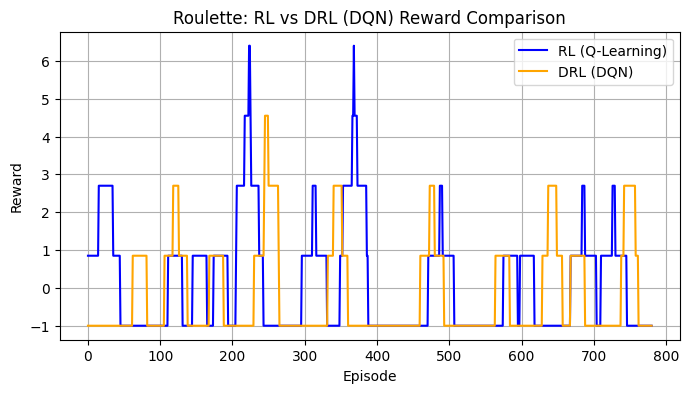

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(np.convolve(rewards_rl, np.ones(20)/20, mode='valid'), label="RL (Q-Learning)", color='blue')
plt.plot(np.convolve(rewards_dqn, np.ones(20)/20, mode='valid'), label="DRL (DQN)", color='orange')
plt.title("Roulette: RL vs DRL (DQN) Reward Comparison")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.legend()
plt.show()

## DISCUSSION

**ANALYSIS OF ROULETTE: RL VS DRL (DQN) REWARD COMPARISON**

1. **Overall Reward Pattern** – Both Q-Learning (blue) and DQN (orange) show highly fluctuating rewards due to the **stochastic nature of roulette**, where outcomes depend largely on chance.

2. **RL (Q-Learning) Behavior** – The blue line occasionally reaches higher reward peaks (around 6), indicating that **Q-learning manages to exploit favorable patterns** slightly better through value updates.

3. **DRL (DQN) Behavior** – The orange line shows more moderate but frequent spikes, meaning **DQN adapts steadily** yet remains limited because roulette lacks continuous state dynamics for deep learning advantage.

4. **Learning Stability** – Both curves show unstable reward trends without consistent growth, suggesting **no sustained learning**, as the environment gives almost random feedback with minimal learnable structure.

5. **Overall Comparison** – Q-learning performs **slightly better in short-term reward peaks**, while DQN maintains **more balanced but lower variance performance**. In random, luck-driven environments like roulette, **neither RL nor DRL achieves stable improvement**.


# SHORTEST PATH

## TECHNICAL TERMS

R matrix (Reward matrix) is a table that stores the immediate reward received after taking an action from a particular state.

Q matrix (Quality matrix) is a table that stores the expected long-term reward (future value) of taking a specific action in a given state and following the best policy afterward.


## INSTALLATION

In [ ]:
!pip install numpy networkx matplotlib pandas torch

## IMPORT

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## USER GRAPH

In [ ]:
edges = [(0,1),(1,5),(5,6),(5,4),(1,2),(1,3),(9,10),(2,4),(0,6),(6,7),
         (8,9),(7,8),(1,7),(3,9)]
G = nx.Graph()
G.add_edges_from(edges)
N = G.number_of_nodes()
goal = 10
pos = nx.spring_layout(G, seed=42)


def show_progress(title, agent=None, visited_edges=None):
    plt.figure(figsize=(6,5))
    node_colors = ['lightgray'] * N
    node_colors[goal] = 'green'
    if agent is not None:
        node_colors[agent] = 'orange'
    nx.draw(G, pos, node_color=node_colors, with_labels=True, node_size=350, edge_color='gray')
    if visited_edges:
        nx.draw_networkx_edges(G, pos, edgelist=visited_edges, edge_color='orange', width=2)
    plt.title(title)
    plt.axis('off')
    plt.show()

## RL: Tabular Q-learning

[RL] Episode 20/300 | Reward: 1216.19 | Epsilon: 0.67


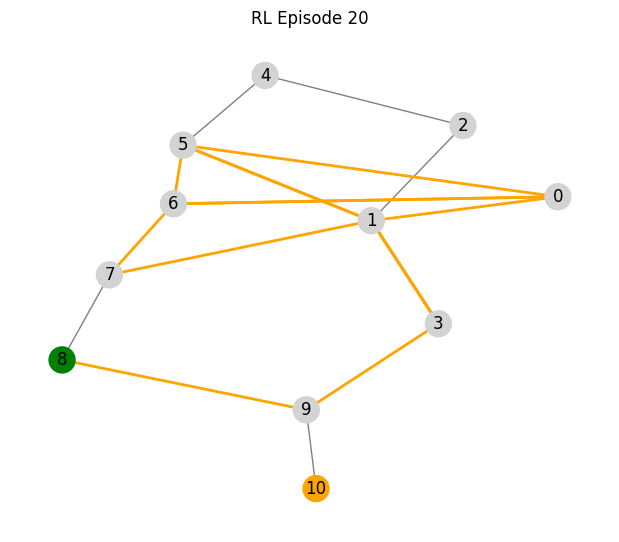

[RL] Episode 40/300 | Reward: 1462.35 | Epsilon: 0.45


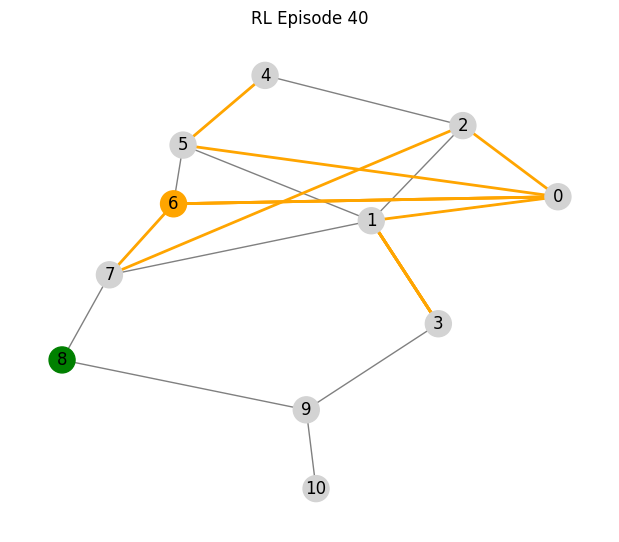

[RL] Episode 60/300 | Reward: 1527.81 | Epsilon: 0.30


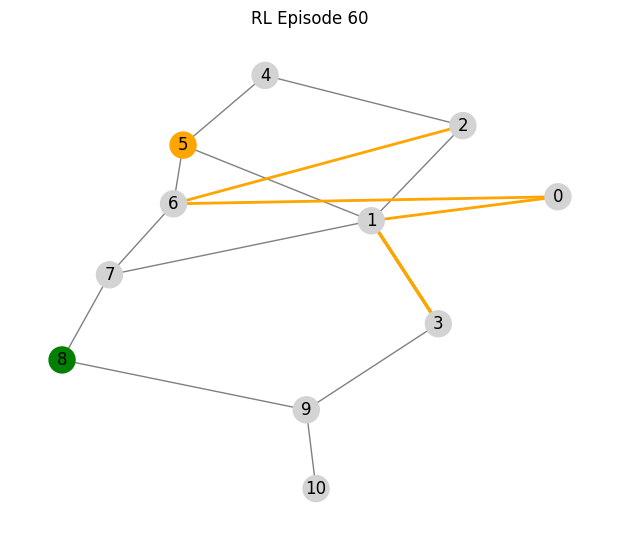

[RL] Episode 80/300 | Reward: 1738.40 | Epsilon: 0.20


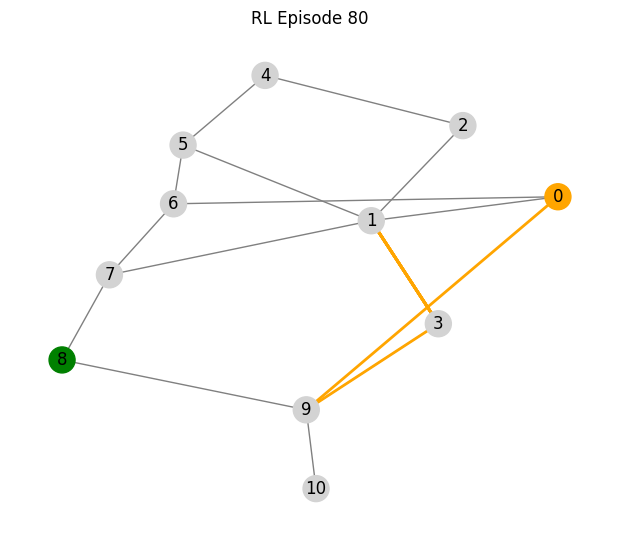

[RL] Episode 100/300 | Reward: 1801.79 | Epsilon: 0.13


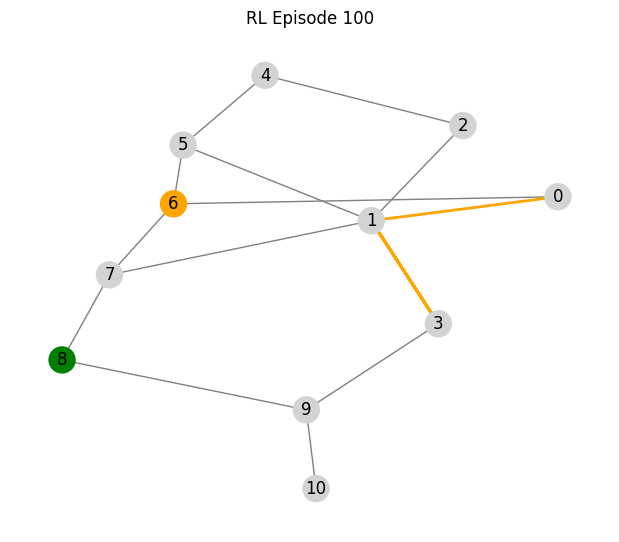

[RL] Episode 120/300 | Reward: 1680.00 | Epsilon: 0.10


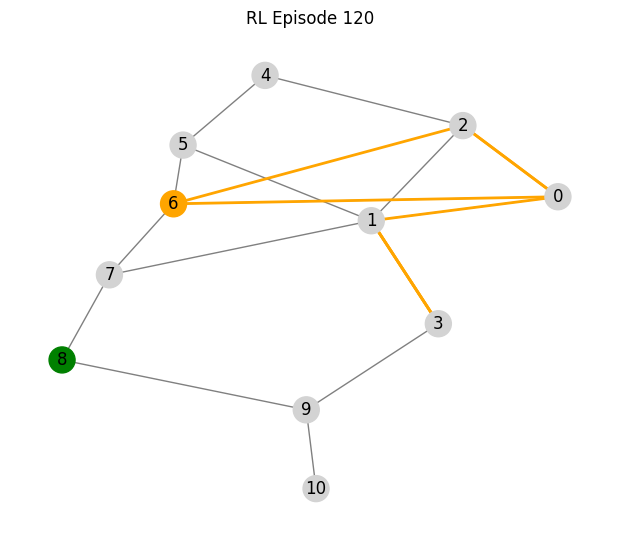

[RL] Episode 140/300 | Reward: 1803.25 | Epsilon: 0.10


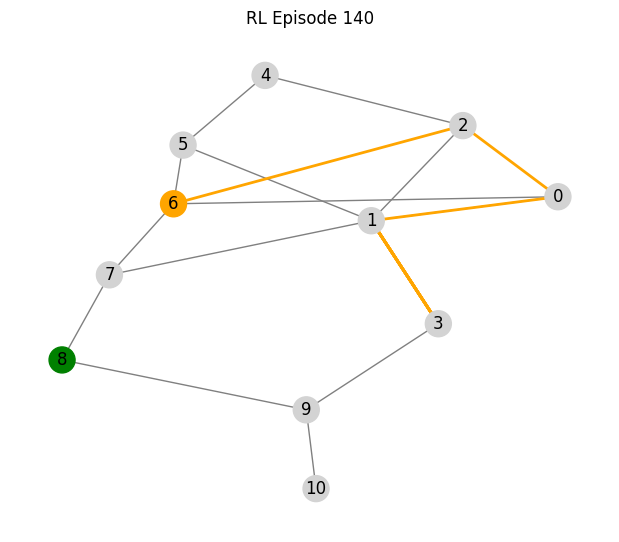

[RL] Episode 160/300 | Reward: 1617.93 | Epsilon: 0.10


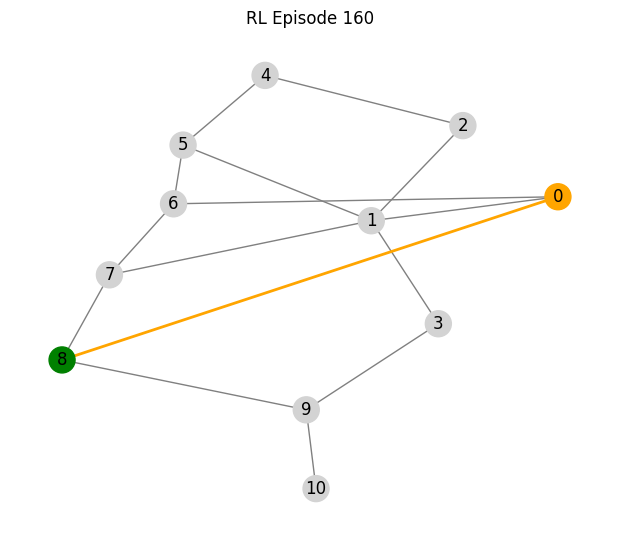

[RL] Episode 180/300 | Reward: 1946.69 | Epsilon: 0.10


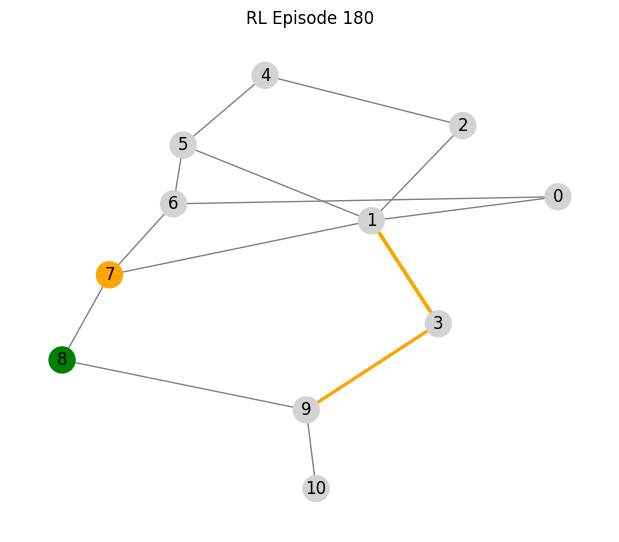

[RL] Episode 200/300 | Reward: 1816.34 | Epsilon: 0.10


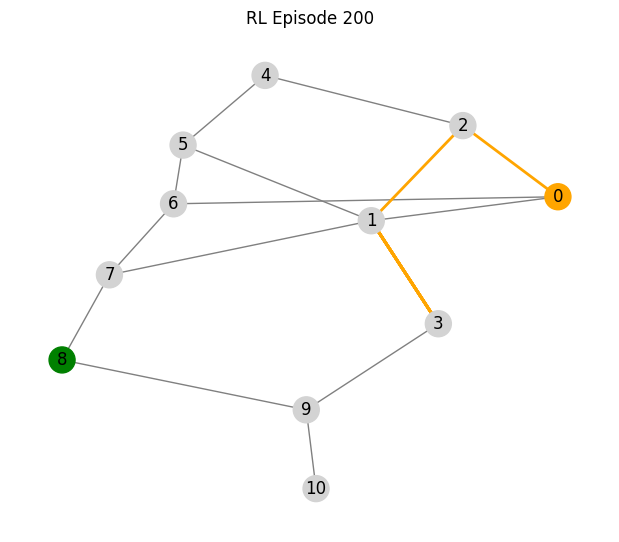

[RL] Episode 220/300 | Reward: 1891.02 | Epsilon: 0.10


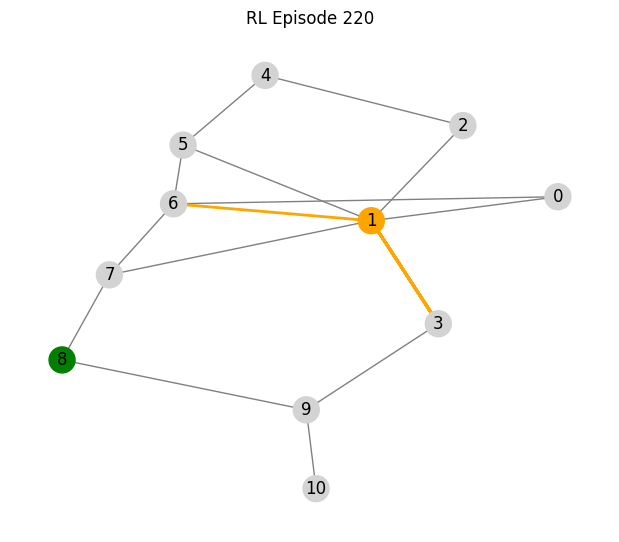

[RL] Episode 240/300 | Reward: 1891.02 | Epsilon: 0.10


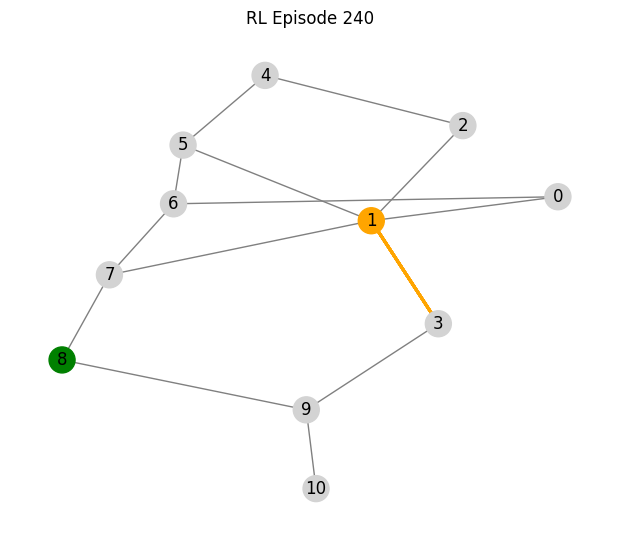

[RL] Episode 260/300 | Reward: 2334.92 | Epsilon: 0.10


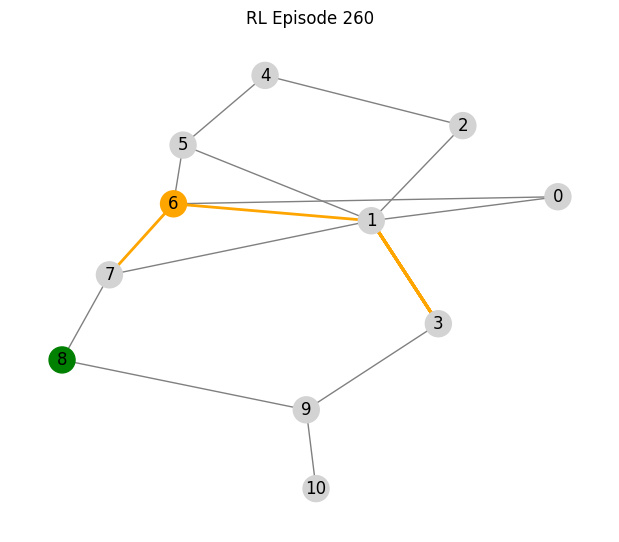

[RL] Episode 280/300 | Reward: 2213.34 | Epsilon: 0.10


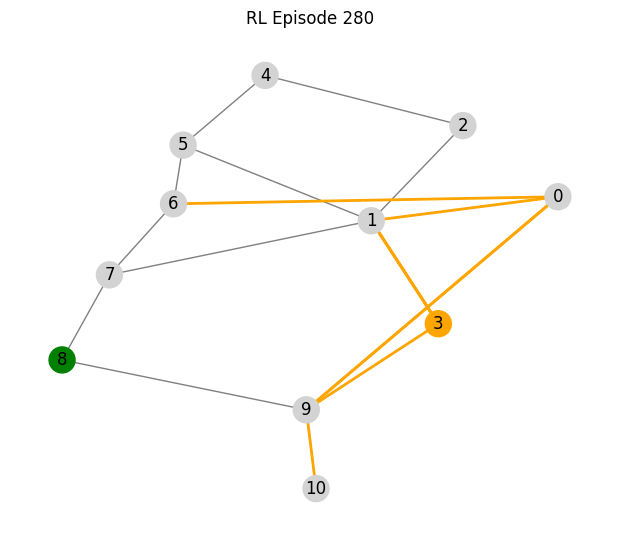

[RL] Episode 300/300 | Reward: 2033.73 | Epsilon: 0.10


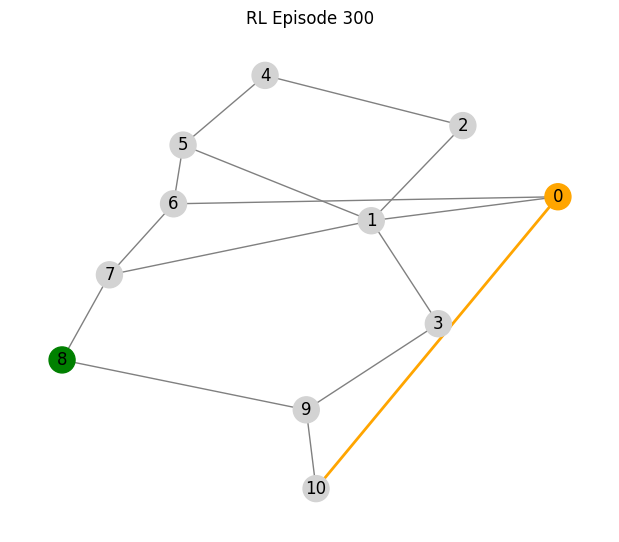

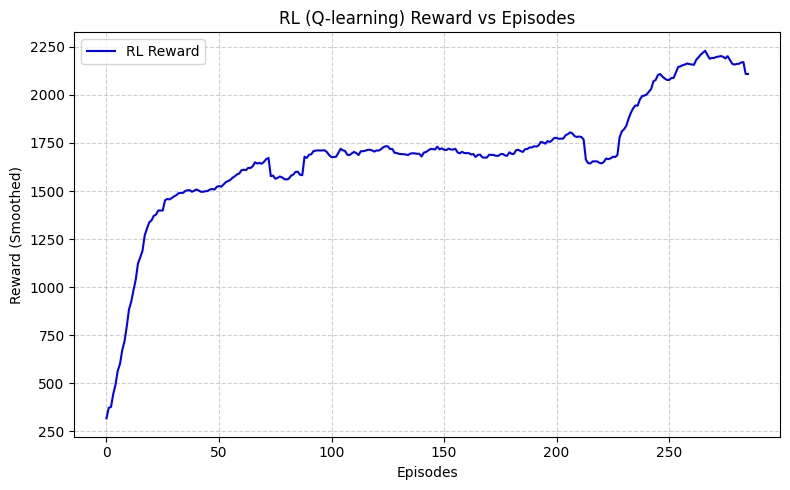

In [ ]:
R = np.zeros((N, N))
Q = np.full((N, N), -100.0)

# reward setup
for u in G[goal]:
    R[u, goal] = 100.0
for u in G.nodes():
    for v in G[u]:
        Q[u, v] = 0.0
        Q[v, u] = 0.0

alpha = 0.7
gamma = 0.9
eps = 1.0
eps_min = 0.1
eps_decay = 0.98
episodes_rl = 300

rewards_rl = []

for ep in range(episodes_rl):
    state = random.randint(0, N - 1)
    visited_edges = []
    total_reward = 0

    for _ in range(15):
        possible_next = list(G[state])

        # epsilon-greedy
        if random.random() < eps:
            next_ = random.choice(possible_next)
        else:
            next_ = int(np.argmax(Q[state, possible_next]))

        max_q = np.max(Q[next_, :])
        Q[state, next_] = (1 - alpha) * Q[state, next_] + alpha * (R[state, next_] + gamma * max_q)

        total_reward += Q[state, next_]
        visited_edges.append((state, next_))
        state = next_

        if state == goal:
            break

    rewards_rl.append(total_reward)

    if eps > eps_min:
        eps *= eps_decay

    if (ep + 1) % 20 == 0:
        print(f"[RL] Episode {ep+1}/{episodes_rl} | Reward: {total_reward:.2f} | Epsilon: {eps:.2f}")
        show_progress(f"RL Episode {ep+1}", agent=state, visited_edges=visited_edges)


def smooth(data, w=15):
    return np.convolve(data, np.ones(w) / w, mode='valid')

plt.figure(figsize=(8,5))
plt.plot(smooth(rewards_rl), color='blue', label="RL Reward", linewidth=1.5)
plt.xlabel("Episodes")
plt.ylabel("Reward (Smoothed)")
plt.title("RL (Q-learning) Reward vs Episodes")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


DISCUSSION

**ANALYSIS OF RL (Q-LEARNING) REWARD VS EPISODES**

1. **Reward Growth** – The curve shows a steady increase in rewards from around 300 to over 2200, indicating that the Q-learning agent is **consistently improving its policy** with experience.

2. **Early Learning Phase** – In the first 50 episodes, the reward rises sharply, showing **fast initial learning** as the agent discovers high-value actions.

3. **Mid Training Stability** – Between 100–200 episodes, the curve flattens, meaning the agent has **reached a near-optimal policy** but continues fine-tuning its behavior.

4. **Late Improvement** – After 200 episodes, rewards climb again, suggesting **further policy refinement** or discovery of even better action paths.

5. **Final Performance** – The high and stable reward level near the end proves that **Q-learning successfully converged**, achieving strong and consistent performance in the environment.


## DRL: DQN Implementation

[DRL] Episode 20/300 | Reward: 78.00 | Epsilon: 0.67


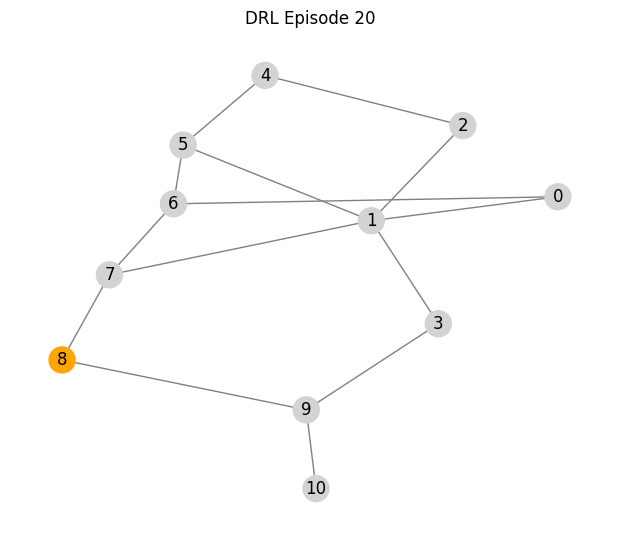

[DRL] Episode 40/300 | Reward: -40.00 | Epsilon: 0.45


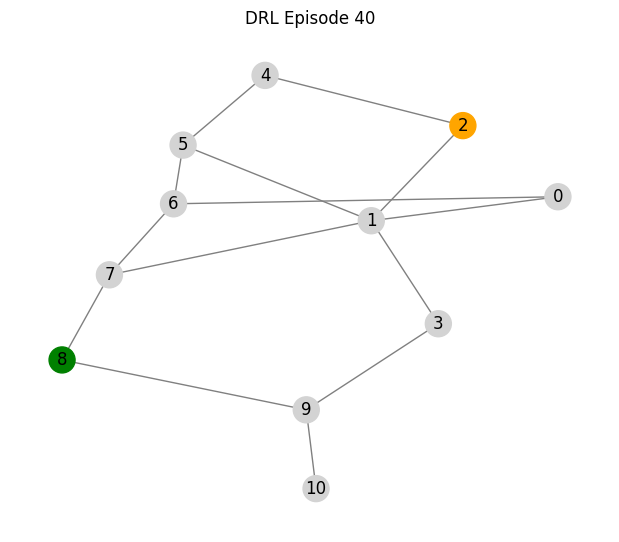

[DRL] Episode 60/300 | Reward: -40.00 | Epsilon: 0.30


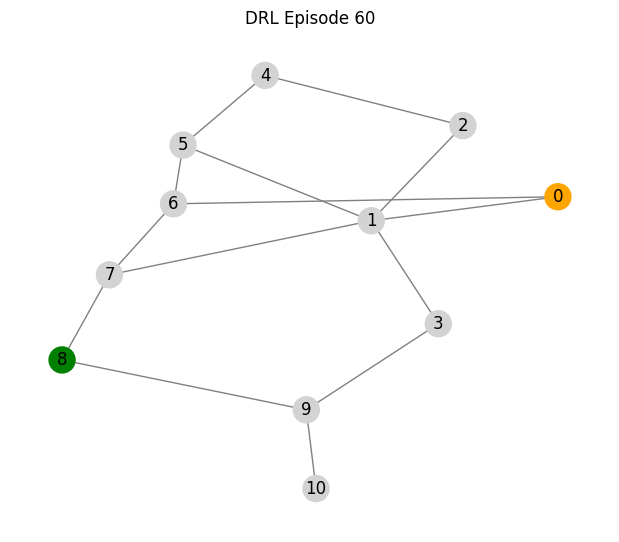

[DRL] Episode 80/300 | Reward: -40.00 | Epsilon: 0.20


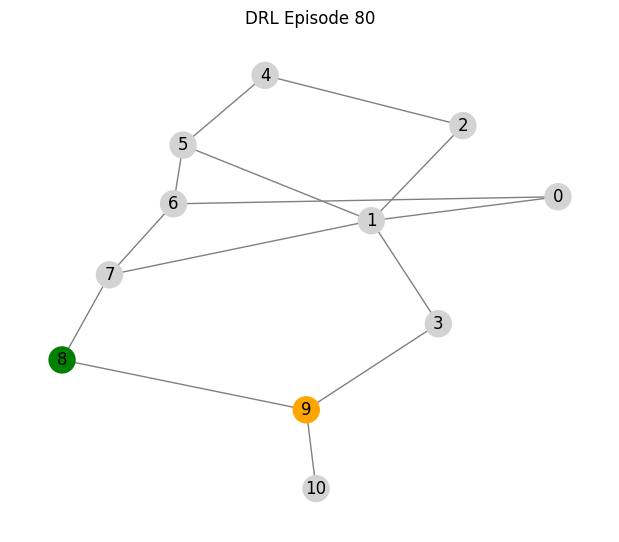

[DRL] Episode 100/300 | Reward: -40.00 | Epsilon: 0.13


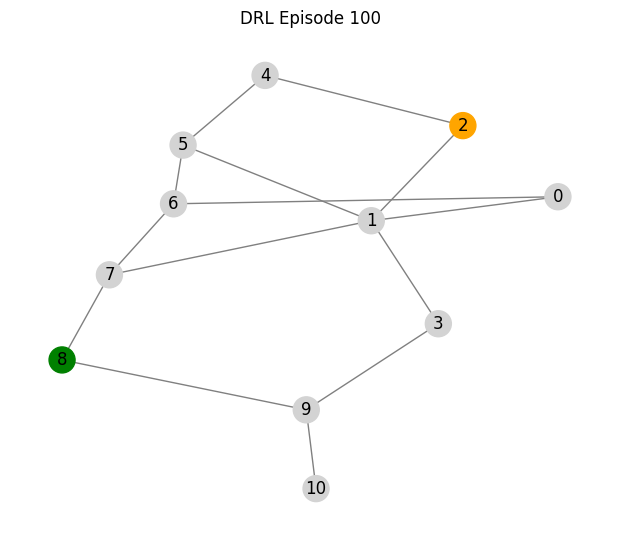

[DRL] Episode 120/300 | Reward: -40.00 | Epsilon: 0.10


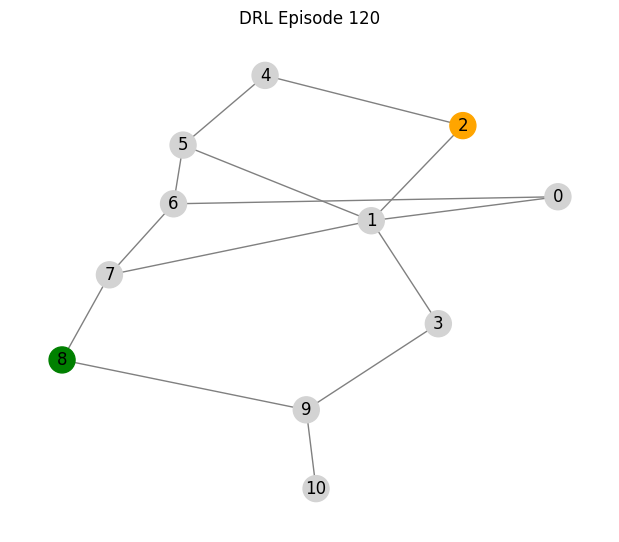

[DRL] Episode 140/300 | Reward: -40.00 | Epsilon: 0.10


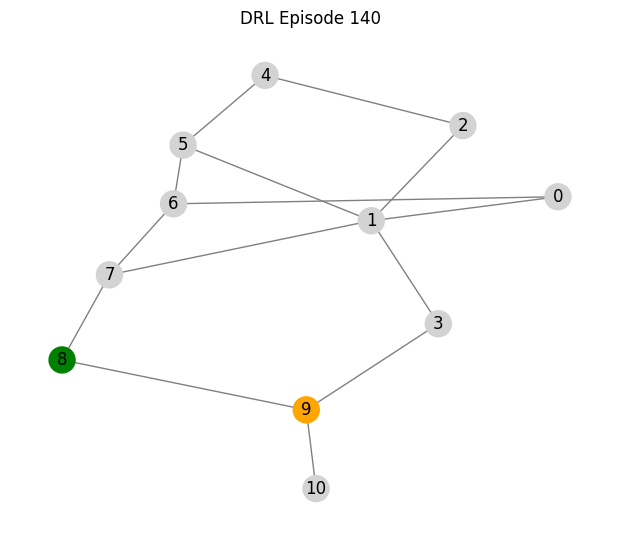

[DRL] Episode 160/300 | Reward: -40.00 | Epsilon: 0.10


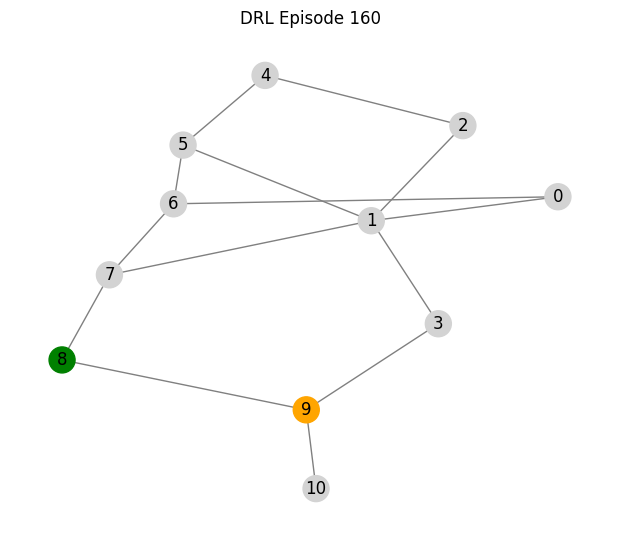

[DRL] Episode 180/300 | Reward: -40.00 | Epsilon: 0.10


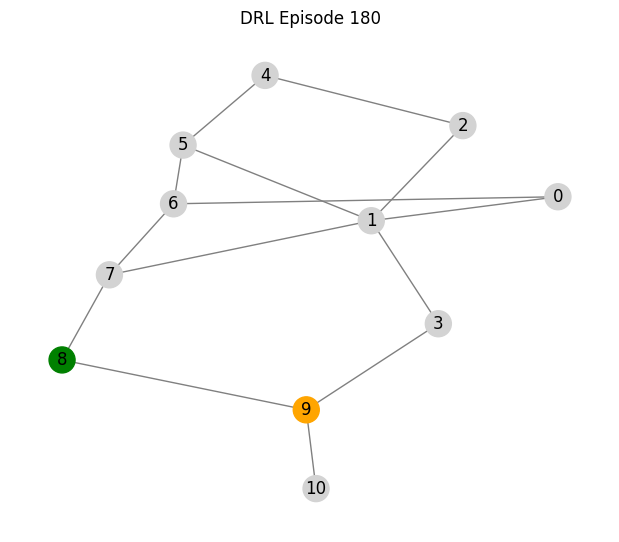

[DRL] Episode 200/300 | Reward: -40.00 | Epsilon: 0.10


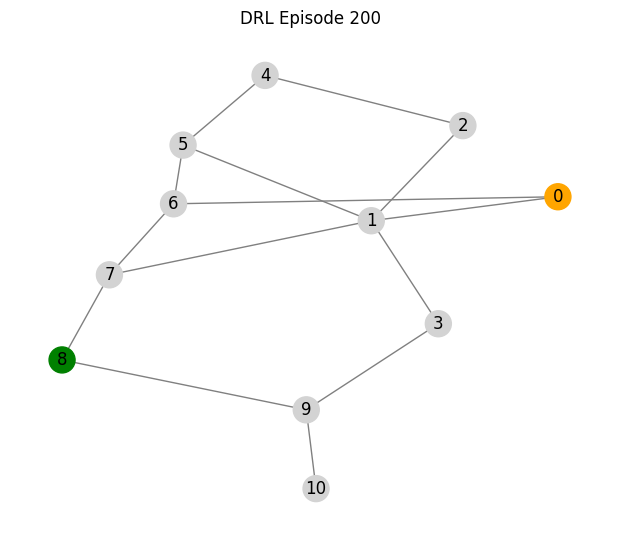

[DRL] Episode 220/300 | Reward: -40.00 | Epsilon: 0.10


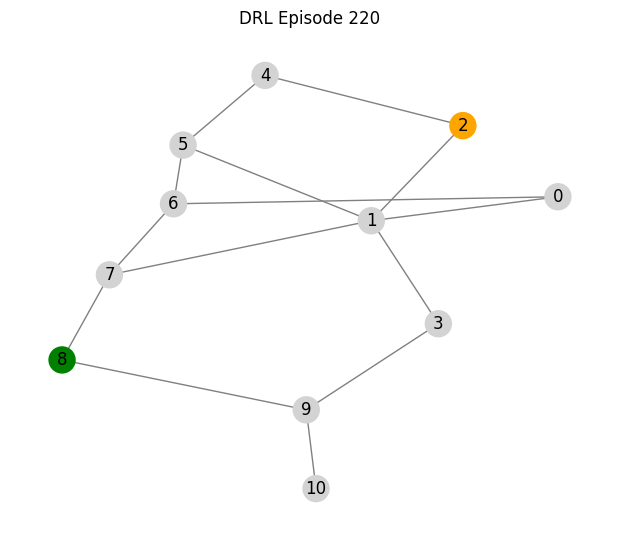

[DRL] Episode 240/300 | Reward: -40.00 | Epsilon: 0.10


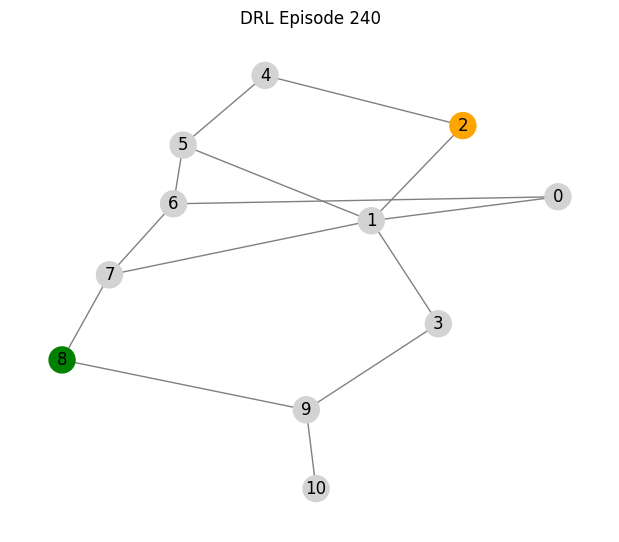

[DRL] Episode 260/300 | Reward: -40.00 | Epsilon: 0.10


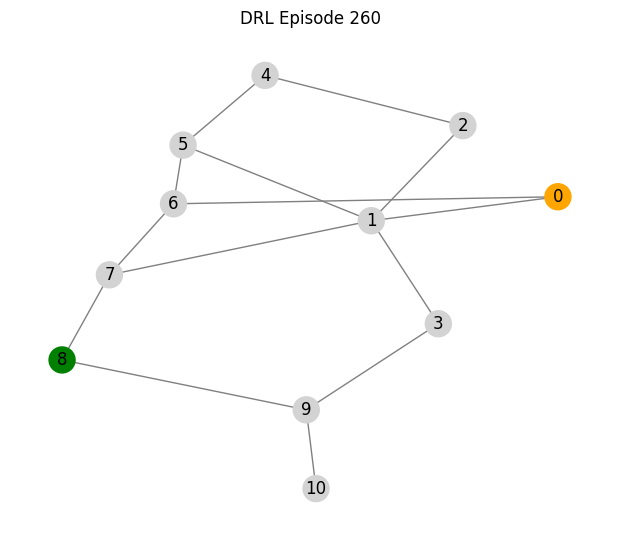

[DRL] Episode 280/300 | Reward: -40.00 | Epsilon: 0.10


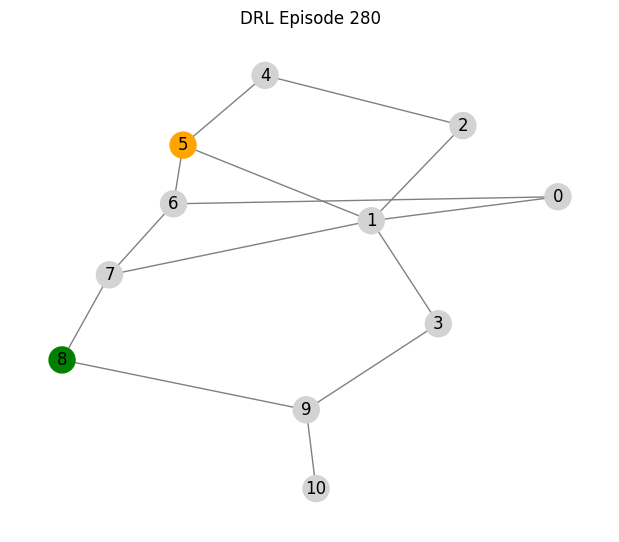

[DRL] Episode 300/300 | Reward: -40.00 | Epsilon: 0.10


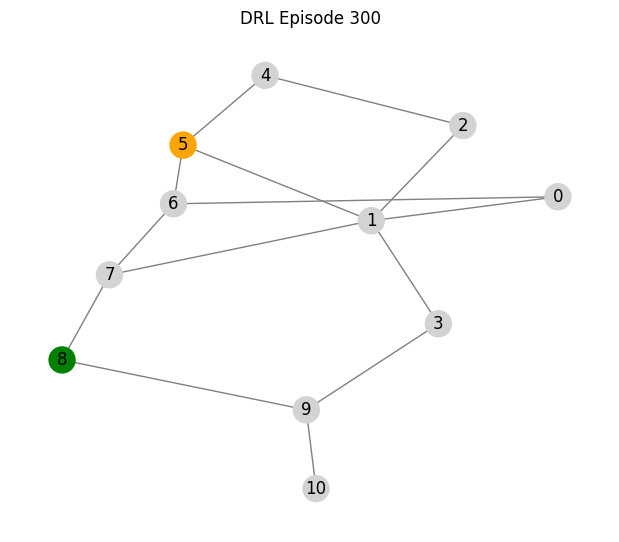

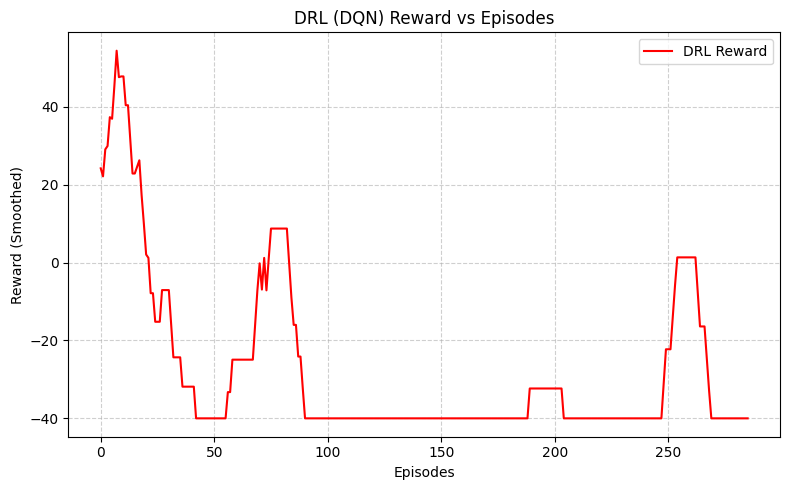

In [ ]:
env = GraphEnv(G, start=0, goal=goal)
policy_net = DQNNet(2*N, N)
target_net = DQNNet(2*N, N)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=0.0005)
loss_fn = nn.MSELoss()

episodes_drl = 300
gamma = 0.9
epsilon = 1.0
epsilon_min = 0.1
epsilon_decay = 0.98

rewards_drl = []

for ep in range(episodes_drl):
    state = env.reset()
    done = False
    total_reward = 0
    visited_edges = []

    while not done:
        if random.random() < epsilon:
            action = int(random.choice(env.valid_actions()))
        else:
            with torch.no_grad():
                qv = policy_net(torch.tensor(state, dtype=torch.float32).unsqueeze(0)).numpy().ravel()
            mask = np.full(env.n, -1e6)
            for a in env.valid_actions():
                mask[a] = qv[a]
            action = int(np.argmax(mask))

        next_state, reward, done, _ = env.step(action)
        total_reward += reward
        visited_edges.append((env.state, action))

        q_values = policy_net(torch.tensor(state, dtype=torch.float32))
        with torch.no_grad():
            q_next = target_net(torch.tensor(next_state, dtype=torch.float32))
            max_next = torch.max(q_next)
            target = q_values.clone()
            target[action] = reward + gamma * max_next * (not done)
        optimizer.zero_grad()
        loss = loss_fn(q_values, target)
        loss.backward()
        optimizer.step()

        state = next_state

    rewards_drl.append(total_reward)

    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    if (ep + 1) % 10 == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if (ep + 1) % 20 == 0:
        print(f"[DRL] Episode {ep+1}/{episodes_drl} | Reward: {total_reward:.2f} | Epsilon: {epsilon:.2f}")
        show_progress(f"DRL Episode {ep+1}", agent=env.state, visited_edges=visited_edges)


def smooth(data, w=15):
    return np.convolve(data, np.ones(w)/w, mode='valid')

plt.figure(figsize=(8,5))
plt.plot(smooth(rewards_drl), color='red', label="DRL Reward", linewidth=1.5)
plt.xlabel("Episodes")
plt.ylabel("Reward (Smoothed)")
plt.title("DRL (DQN) Reward vs Episodes")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

DISCUSSION

**ANALYSIS OF DRL (DQN) REWARD VS EPISODES**

1. **Initial High Reward** – At the start, rewards increase quickly and reach above 40, showing that the DQN agent initially explores some effective actions randomly.

2. **Sharp Decline** – After the early rise, rewards fall steeply and remain negative for most episodes, indicating **unstable learning or poor policy updates**.

3. **Intermittent Spikes** – Occasional short peaks reappear, meaning the agent **sometimes finds good actions** but cannot maintain consistency.

4. **Long Negative Phase** – Between 100 and 230 episodes, rewards remain constant around -40, showing the network **fails to improve or gets stuck** in suboptimal behavior.

5. **Overall Performance** – The DQN model shows **training instability and weak convergence**, suggesting a need for **parameter tuning or more training episodes** to achieve stable improvement.


## RL VS DRL COMPARISION

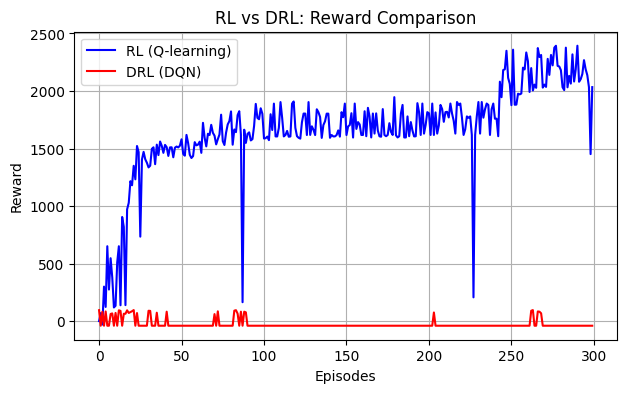

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(rewards_rl, label="RL (Q-learning)", color='blue')
plt.plot(rewards_drl, label="DRL (DQN)", color='red')
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("RL vs DRL: Reward Comparison")
plt.legend()
plt.grid(True)
plt.show()

## DISCUSSION

**ANALYSIS OF RL VS DRL REWARD COMPARISON**

1. **Overall Reward Pattern** – The RL (Q-learning) curve in blue rises sharply and stabilizes at high rewards (around 1500–2200), while the DRL (DQN) curve in red stays near zero, showing minimal learning progress.

2. **RL (Q-learning) Behavior** – Q-learning successfully learns the environment through repeated exploration and exploitation, leading to **steady reward growth and eventual convergence** to a high-performing policy.

3. **DRL (DQN) Behavior** – DQN struggles to improve rewards, suggesting **poor convergence or unstable training**, possibly due to inappropriate neural network design, learning rate, or insufficient state representation.

4. **Learning Stability** – The RL curve shows **minor reward dips** but quickly recovers, indicating stable value updates, while the DRL curve’s flatness shows **lack of effective gradient-based learning**.

5. **Overall Comparison** – In this setup, **Q-learning significantly outperforms DQN**, proving that **simpler tabular RL methods can excel** when the environment is discrete, low-dimensional, or when DQN hyperparameters are not well tuned.
